In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

class BidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 256, 10], alpha_gen=1.0, alpha_disc=1.0):
        super().__init__()
        self.L = len(layer_sizes)
        # alpha_disc doit souvent être supérieur à alpha_gen pour compenser la magnitude des erreurs top-down
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        # Poids discriminatifs (Bottom-up) : V
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        
        # Poids génératifs (Top-down) : W
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        
        # Fonction d'activation (LeakyReLU est très performant selon le papier)
        self.activation = nn.LeakyReLU()

    def compute_energy(self, x):
        """Calcule l'énergie globale E(x, W, V) du réseau."""
        energy_gen = 0.0
        energy_disc = 0.0
        
        for i in range(self.L - 1):
            # Erreur générative top-down (x_l prédit par W_{l+1} * f(x_{l+1}))
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2)
            
            # Erreur discriminative bottom-up (x_{l+1} prédit par V_l * f(x_l))
            pred_disc = self.V[i](self.activation(x[i]))
            energy_disc += torch.sum((x[i+1] - pred_disc) ** 2)
            
        return (self.alpha_gen / 2) * energy_gen + (self.alpha_disc / 2) * energy_disc

    def bottom_up_sweep(self, x1):
        """Initialisation rapide feedforward pour stabiliser/accélérer l'inférence."""
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01):
        """
        Phase d'inférence : descente de gradient sur les activations neurales x.
        """
        x = [t.clone() for t in x_init]
        
        # Seules les couches non-clampées sont mises à jour
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            # Optimisation locale des activités (SGD avec momentum optionnel)
            optimizer_x = optim.SGD(free_params, lr=lr_x)
            
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                optimizer_x.step()
                
        return [t.detach() for t in x]

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import math

# 1. Classe bPC (mise à jour avec la propagation top-down pour l'init générative)
class BidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 256, 256, 10], alpha_gen=1e-4, alpha_disc=1.0):
        super().__init__()
        self.L = len(layer_sizes)
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        self.activation = nn.LeakyReLU()

    def compute_energy(self, x):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2)
            
            pred_disc = self.V[i](self.activation(x[i]))
            energy_disc += torch.sum((x[i+1] - pred_disc) ** 2)
            
        return (self.alpha_gen / 2) * energy_gen + (self.alpha_disc / 2) * energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def top_down_sweep(self, xL):
        """Ajouté pour l'initialisation générative exacte du papier"""
        x = [None] * self.L
        x[-1] = xL.clone()
        with torch.no_grad():
            for i in range(self.L - 2, -1, -1):
                x[i] = self.W[i](self.activation(x[i+1]))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01):
        x = [t.clone() for t in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                optimizer_x.step()
                
        return [t.detach() for t in x]

# 2. Préparation des données (Normalisation entre -1 et 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Ramène les valeurs de [0, 1] à [-1, 1]
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Calcul des images moyennes par classe pour la métrique RMSE générative
class_sums = torch.zeros((10, 784), device=device)
class_counts = torch.zeros(10, device=device)

for images, labels in testloader:
    images = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    for i in range(10):
        mask = (labels == i)
        if mask.any():
            class_sums[i] += images[mask].sum(dim=0)
            class_counts[i] += mask.sum()

class_averages = class_sums / class_counts.unsqueeze(1)

# 4. Initialisation du modèle et de l'optimiseur
model = BidirectionalPC(layer_sizes=[784, 256, 256, 10], alpha_gen=1e-4, alpha_disc=1.0).to(device)
optimizer_theta = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)

# 5. Boucle d'entraînement
epochs = 25
print(f"Début de l'entraînement sur {device}...")

for epoch in range(epochs):
    model.train()
    total_energy = 0
    
    for images, labels in trainloader:
        x1_input = images.view(images.size(0), -1).to(device)
        xL_label = torch.nn.functional.one_hot(labels, num_classes=10).float().to(device)
        
        # Initialisation
        x_init = model.bottom_up_sweep(x1_input)
        x_init[0] = x1_input
        x_init[-1] = xL_label
        
        # Inférence avec T=8
        x_inferred = model.infer(x_init, clamped_indices=[0, 3], steps=8, lr_x=0.01)
        
        # Mise à jour des poids
        optimizer_theta.zero_grad()
        loss = model.compute_energy(x_inferred)
        loss.backward()
        optimizer_theta.step()
        
        total_energy += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Energie moyenne: {total_energy/len(trainloader):.4f}")

# 6. Évaluation des performances
model.eval()

# --- Précision de Classification ---
correct = 0
total = 0

for images, labels in testloader:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    
    x_init = model.bottom_up_sweep(x1_input)
    # T_eval = 100
    x_res = model.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    predictions = torch.argmax(x_res[-1], dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = 100 * correct / total
print(f"\n[Métrique Discriminative] Précision de classification : {accuracy:.2f}%")

# --- RMSE de Génération Conditionnelle ---
total_mse = 0
total_gen_samples = 0

# On génère un batch contenant toutes les classes (0 à 9)
target_classes = torch.arange(10).to(device)
xL_target = torch.nn.functional.one_hot(target_classes, num_classes=10).float()

# Initialisation générative top-down
x_init_gen = model.top_down_sweep(xL_target)
# T_eval = 100
x_res_gen = model.infer(x_init_gen, clamped_indices=[3], steps=100, lr_x=0.01)

generated_images = x_res_gen[0]

# Calcul du RMSE par rapport aux images moyennes de chaque classe
mse = torch.mean((generated_images - class_averages) ** 2)
rmse = math.sqrt(mse.item())

print(f"[Métrique Générative] RMSE (Génération conditionnelle) : {rmse:.4f}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 135MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 42.4MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 135MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.3MB/s]


Début de l'entraînement sur cuda...
Epoch 1/25 | Energie moyenne: 68.8648
Epoch 2/25 | Energie moyenne: 36.9913
Epoch 3/25 | Energie moyenne: 27.7185
Epoch 4/25 | Energie moyenne: 23.1414
Epoch 5/25 | Energie moyenne: 20.3399
Epoch 6/25 | Energie moyenne: 18.4258
Epoch 7/25 | Energie moyenne: 16.9595
Epoch 8/25 | Energie moyenne: 15.8089
Epoch 9/25 | Energie moyenne: 14.8385
Epoch 10/25 | Energie moyenne: 13.9854
Epoch 11/25 | Energie moyenne: 13.2645
Epoch 12/25 | Energie moyenne: 12.6163
Epoch 13/25 | Energie moyenne: 12.0341
Epoch 14/25 | Energie moyenne: 11.5303
Epoch 15/25 | Energie moyenne: 11.0501
Epoch 16/25 | Energie moyenne: 10.6392
Epoch 17/25 | Energie moyenne: 10.2449
Epoch 18/25 | Energie moyenne: 9.8897
Epoch 19/25 | Energie moyenne: 9.5467
Epoch 20/25 | Energie moyenne: 9.2358
Epoch 21/25 | Energie moyenne: 8.9354
Epoch 22/25 | Energie moyenne: 8.6770
Epoch 23/25 | Energie moyenne: 8.4110
Epoch 24/25 | Energie moyenne: 8.1853
Epoch 25/25 | Energie moyenne: 7.9503

[Métr

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import math

# 1. Définition du Modèle bPC (Dynamique)
class BidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 450, 10], alpha_gen=1e-4, alpha_disc=1.0):
        super().__init__()
        self.L = len(layer_sizes)
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        # Bottom-up weights V
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        # Top-down weights W
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        self.activation = nn.LeakyReLU()

    def compute_energy(self, x):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2)
            
            pred_disc = self.V[i](self.activation(x[i]))
            energy_disc += torch.sum((x[i+1] - pred_disc) ** 2)
            
        return (self.alpha_gen / 2) * energy_gen + (self.alpha_disc / 2) * energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def top_down_sweep(self, xL):
        x = [None] * self.L
        x[-1] = xL.clone()
        with torch.no_grad():
            for i in range(self.L - 2, -1, -1):
                x[i] = self.W[i](self.activation(x[i+1]))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01):
        x = [t.clone() for t in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                optimizer_x.step()
                
        return [t.detach() for t in x]

# 2. Chargement et Normalisation de MNIST [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Calcul des images moyennes par classe pour la métrique RMSE
class_sums = torch.zeros((10, 784), device=device)
class_counts = torch.zeros(10, device=device)

for images, labels in testloader:
    images = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    for i in range(10):
        mask = (labels == i)
        if mask.any():
            class_sums[i] += images[mask].sum(dim=0)
            class_counts[i] += mask.sum()

class_averages = class_sums / class_counts.unsqueeze(1)

# 4. Initialisation avec la configuration cible [784, 450, 10]
layer_configuration = [784, 450, 10]
model = BidirectionalPC(layer_sizes=layer_configuration, alpha_gen=1e-4, alpha_disc=1.0).to(device)
optimizer_theta = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)

# 5. Entraînement bPC
epochs = 25
print(f"Début de l'entraînement avec l'architecture {layer_configuration} sur {device}...")

for epoch in range(epochs):
    model.train()
    total_energy = 0
    
    for images, labels in trainloader:
        x1_input = images.view(images.size(0), -1).to(device)
        xL_label = torch.nn.functional.one_hot(labels, num_classes=10).float().to(device)
        
        # Initialisation bottom-up
        x_init = model.bottom_up_sweep(x1_input)
        x_init[0] = x1_input
        x_init[-1] = xL_label
        
        # Inférence locale (T = 8)
        x_inferred = model.infer(x_init, clamped_indices=[0, model.L - 1], steps=8, lr_x=0.01)
        
        # Apprentissage des poids (Descente de gradient)
        optimizer_theta.zero_grad()
        loss = model.compute_energy(x_inferred)
        loss.backward()
        optimizer_theta.step()
        
        total_energy += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Energie moyenne: {total_energy/len(trainloader):.4f}")

# 6. Évaluation finale
model.eval()

# --- Évaluation Discriminative (Classification) ---
correct = 0
total = 0

for images, labels in testloader:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    
    x_init = model.bottom_up_sweep(x1_input)
    # T_eval = 100
    x_res = model.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    predictions = torch.argmax(x_res[-1], dim=1)
    correct += (predictions == labels).sum().item()
    total += labels.size(0)

accuracy = 100 * correct / total
print(f"\n[Métrique Discriminative] Précision de classification : {accuracy:.2f}%")

# --- Évaluation Générative (RMSE) ---
target_classes = torch.arange(10).to(device)
xL_target = torch.nn.functional.one_hot(target_classes, num_classes=10).float()

# Initialisation top-down
x_init_gen = model.top_down_sweep(xL_target)
# T_eval = 100
x_res_gen = model.infer(x_init_gen, clamped_indices=[model.L - 1], steps=100, lr_x=0.01)

generated_images = x_res_gen[0]

# Calcul du RMSE
mse = torch.mean((generated_images - class_averages) ** 2)
rmse = math.sqrt(mse.item())

print(f"[Métrique Générative] RMSE (Génération conditionnelle) : {rmse:.4f}")

Début de l'entraînement avec l'architecture [784, 450, 10] sur cuda...
Epoch 1/25 | Energie moyenne: 63.2937
Epoch 2/25 | Energie moyenne: 35.6540
Epoch 3/25 | Energie moyenne: 27.8545
Epoch 4/25 | Energie moyenne: 23.8401
Epoch 5/25 | Energie moyenne: 21.2520
Epoch 6/25 | Energie moyenne: 19.3510
Epoch 7/25 | Energie moyenne: 17.8740
Epoch 8/25 | Energie moyenne: 16.6972
Epoch 9/25 | Energie moyenne: 15.7186
Epoch 10/25 | Energie moyenne: 14.8910
Epoch 11/25 | Energie moyenne: 14.1757
Epoch 12/25 | Energie moyenne: 13.5674
Epoch 13/25 | Energie moyenne: 13.0227
Epoch 14/25 | Energie moyenne: 12.5069
Epoch 15/25 | Energie moyenne: 12.0610
Epoch 16/25 | Energie moyenne: 11.6685
Epoch 17/25 | Energie moyenne: 11.3031
Epoch 18/25 | Energie moyenne: 10.9559
Epoch 19/25 | Energie moyenne: 10.6293
Epoch 20/25 | Energie moyenne: 10.3499
Epoch 21/25 | Energie moyenne: 10.0766
Epoch 22/25 | Energie moyenne: 9.8251
Epoch 23/25 | Energie moyenne: 9.5844
Epoch 24/25 | Energie moyenne: 9.3652
Epoch

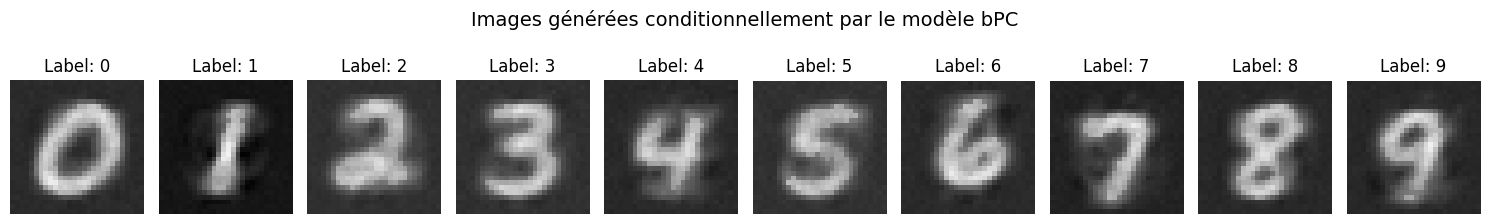

In [4]:
import matplotlib.pyplot as plt

# S'assurer que le modèle est en mode évaluation
model.eval()

# 1. Créer les labels cibles : les chiffres de 0 à 9 en one-hot
target_classes = torch.arange(10).to(device)
xL_target = torch.nn.functional.one_hot(target_classes, num_classes=10).float()

# 2. Lancer la génération 
# Initialisation top-down (du label vers l'image)
x_init_gen = model.top_down_sweep(xL_target)
# Inférence : on clampe la dernière couche (les labels) et on laisse le réseau deviner l'image (couche 0)
x_res_gen = model.infer(x_init_gen, clamped_indices=[model.L - 1], steps=100, lr_x=0.01)

# 3. Récupérer les images (couche 0) et les transférer sur le CPU pour l'affichage
generated_images = x_res_gen[0].cpu().numpy()

# 4. Affichage sous forme de grille (1 ligne, 10 colonnes)
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Images générées conditionnellement par le modèle bPC", fontsize=14, y=1.1)

for i in range(10):
    # Les images étaient aplaties en 784, on les remet en 28x28
    img = generated_images[i].reshape(28, 28)
    # Dé-normalisation : on repasse de [-1, 1] à [0, 1] pour un bel affichage
    img_display = (img + 1) / 2.0 
    
    axes[i].imshow(img_display, cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {i}")

plt.tight_layout()
plt.show()

Début de l'inférence pour la complétion (5000 étapes)...


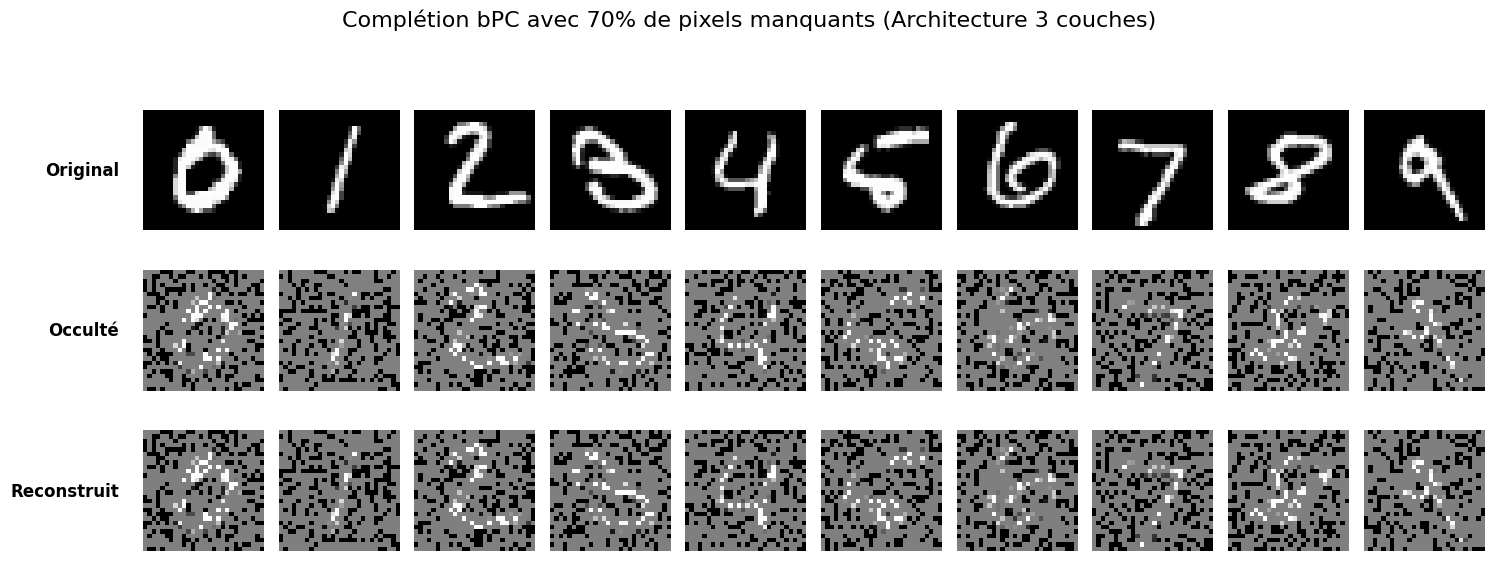

In [5]:
import matplotlib.pyplot as plt
import torch

# S'assurer que le modèle est en mode évaluation
model.eval()

# 1. Récupérer un exemple de chaque chiffre (de 0 à 9) du testset
examples = {}
for images, labels in testloader:
    for img, label in zip(images, labels):
        if label.item() not in examples:
            examples[label.item()] = img.view(784).to(device)
        if len(examples) == 10:
            break
    if len(examples) == 10:
        break

# Trier les images de 0 à 9
original_images = torch.stack([examples[i] for i in range(10)])

# 2. Créer le masque d'occlusion (aléatoire uniforme, comme dans l'article)
missing_ratio = 0.70 # 70% de pixels effacés
# known_mask : 1 = pixel observé, 0 = pixel manquant
known_mask = (torch.rand_like(original_images) > missing_ratio).float()
missing_mask = 1.0 - known_mask

# Initialiser les pixels manquants à zéro (comme stipulé dans le papier)
occluded_images = original_images * known_mask

# 3. Préparer l'inférence
# Initialisation bottom-up à partir des images occultées
x_init = model.bottom_up_sweep(occluded_images)

# On prépare les tenseurs pour la descente de gradient
x = [t.clone().detach() for t in x_init]
for i in range(model.L):
    x[i].requires_grad = True

# Optimiseur pour mettre à jour l'activité des neurones
optimizer_x = torch.optim.SGD(x, lr=0.01)

# L'article mentionne jusqu'à 600 000 étapes. On en fait 5 000 pour la rapidité.
inference_steps = 5000

print(f"Début de l'inférence pour la complétion ({inference_steps} étapes)...")
for step in range(inference_steps):
    optimizer_x.zero_grad()
    energy = model.compute_energy(x)
    energy.backward()
    
    # ASTUCE : Annuler le gradient des pixels observés. 
    # Ainsi, seuls les pixels manquants (où missing_mask == 1) seront modifiés par l'optimiseur.
    x[0].grad.data *= missing_mask
    
    optimizer_x.step()

# Extraire les images reconstruites
completed_images = x[0].detach()

# 4. Affichage comparatif : Original | Occulté | Reconstruit
fig, axes = plt.subplots(3, 10, figsize=(15, 6))
fig.suptitle(f"Complétion bPC avec {int(missing_ratio*100)}% de pixels manquants (Architecture {model.L} couches)", fontsize=16, y=0.98)

titles = ["Original", "Occulté", "Reconstruit"]
tensors_to_plot = [original_images, occluded_images, completed_images]

for row in range(3):
    for col in range(10):
        # Repasser en 28x28 et sur le CPU
        img = tensors_to_plot[row][col].cpu().numpy().reshape(28, 28)
        # Dénormaliser de [-1, 1] vers [0, 1]
        img_display = (img + 1) / 2.0  
        
        axes[row, col].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        
        # Ajouter le titre de ligne sur la première colonne
        if col == 0:
            axes[row, col].text(-0.2, 0.5, titles[row], va='center', ha='right', 
                                transform=axes[row, col].transAxes, fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Début de l'entraînement avec [784, 450, 30] sur cuda (10 labels + 20 neurones libres)...
Epoch 1/25 | Energie moyenne: 0.9373
Epoch 2/25 | Energie moyenne: 0.3627
Epoch 3/25 | Energie moyenne: 0.2168
Epoch 4/25 | Energie moyenne: 0.1602
Epoch 5/25 | Energie moyenne: 0.1333
Epoch 6/25 | Energie moyenne: 0.1177
Epoch 7/25 | Energie moyenne: 0.1067
Epoch 8/25 | Energie moyenne: 0.0990
Epoch 9/25 | Energie moyenne: 0.0932
Epoch 10/25 | Energie moyenne: 0.0883
Epoch 11/25 | Energie moyenne: 0.0843
Epoch 12/25 | Energie moyenne: 0.0814
Epoch 13/25 | Energie moyenne: 0.0784
Epoch 14/25 | Energie moyenne: 0.0761
Epoch 15/25 | Energie moyenne: 0.0745
Epoch 16/25 | Energie moyenne: 0.0721
Epoch 17/25 | Energie moyenne: 0.0705
Epoch 18/25 | Energie moyenne: 0.0694
Epoch 19/25 | Energie moyenne: 0.0681
Epoch 20/25 | Energie moyenne: 0.0669
Epoch 21/25 | Energie moyenne: 0.0653
Epoch 22/25 | Energie moyenne: 0.0649
Epoch 23/25 | Energie moyenne: 0.0634
Epoch 24/25 | Energie moyenne: 0.0628
Epoch 25

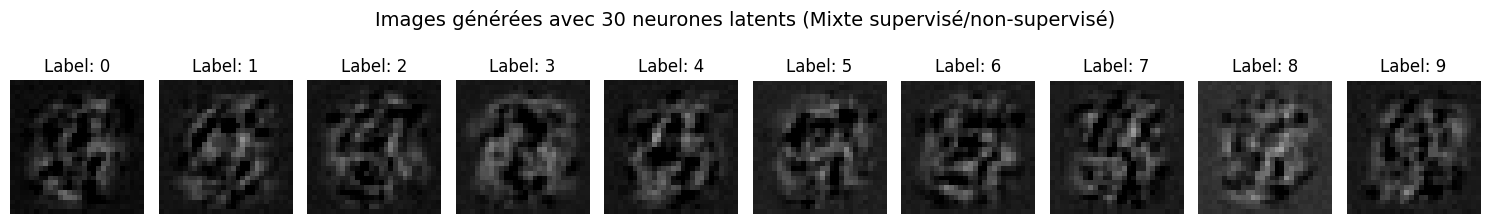

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import math
import matplotlib.pyplot as plt

class BidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 450, 30], alpha_gen=1e-4, alpha_disc=1.0, num_labels=10):
        super().__init__()
        self.L = len(layer_sizes)
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        # Poids Bottom-up (V) et Top-down (W)
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        self.activation = nn.LeakyReLU()

        # Création du vecteur alpha_disc spécifique pour la couche latente x_L
        # Les 10 premiers neurones (labels) gardent la valeur forte alpha_disc (1.0)
        alpha_disc_L = torch.ones(layer_sizes[-1]) * alpha_disc
        # Les 20 neurones suivants (libres) prennent la valeur faible alpha_gen (1e-4) pour équilibrer la tâche non supervisée
        alpha_disc_L[num_labels:] = alpha_gen
        
        # register_buffer permet de sauvegarder ce tenseur dans le modèle 
        # pour qu'il soit automatiquement basculé sur le GPU/CPU avec .to(device)
        self.register_buffer('alpha_disc_L', alpha_disc_L)

    def compute_energy(self, x):
        energy_gen = 0.0
        energy_disc = 0.0
        
        for i in range(self.L - 1):
            # Erreur générative (top-down) : pondération constante par alpha_gen
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2) * (self.alpha_gen / 2)
            
            # Erreur discriminative (bottom-up)
            pred_disc = self.V[i](self.activation(x[i]))
            diff_sq_disc = (x[i+1] - pred_disc) ** 2
            
            if i == self.L - 2:
                # Sur la toute dernière couche, on applique la pondération neurone par neurone
                # La multiplication s'opère terme à terme (broadcasting) sur le tenseur de taille 30
                energy_disc += torch.sum(diff_sq_disc * self.alpha_disc_L) / 2
            else:
                # Sur les couches cachées classiques, on applique le scalaire alpha_disc
                energy_disc += torch.sum(diff_sq_disc) * (self.alpha_disc / 2)
                
        return energy_gen + energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def top_down_sweep(self, xL):
        x = [None] * self.L
        x[-1] = xL.clone()
        with torch.no_grad():
            for i in range(self.L - 2, -1, -1):
                x[i] = self.W[i](self.activation(x[i+1]))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01, partial_clamp=None):
        x = [t.clone() for t in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                
                # Gestion du clampage partiel (pour figer uniquement les labels dans x_L)
                if partial_clamp is not None:
                    layer_idx, mask = partial_clamp
                    if x[layer_idx].requires_grad:
                        x[layer_idx].grad.data *= (1.0 - mask)
                
                optimizer_x.step()
                
        return [t.detach() for t in x]


# 2. Préparation des données [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

from torch.utils.data import random_split

# Remplacer le chargement précédent par :
full_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Séparation 50k / 10k exacte
trainset, valset = random_split(full_trainset, [50000, 10000])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True) # Fontaine utilise des batchs de 64
valloader = torch.utils.data.DataLoader(valset, batch_size=64, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Architecture : Entrée 784, Cachée 450, Latente 30 (10 labels + 20 libres)
layer_configuration = [784, 450, 30]
model = BidirectionalPC(layer_sizes=layer_configuration, alpha_gen=1e-4, alpha_disc=1.0).to(device)
optimizer_theta = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)

epochs = 25
print(f"Début de l'entraînement avec {layer_configuration} sur {device} (10 labels + 20 neurones libres)...")

# Mask pour la couche latente : 1 pour les 10 premiers neurones (labels), 0 pour le reste
latent_mask = torch.zeros(30, device=device)
latent_mask[:10] = 1.0

for epoch in range(epochs):
    model.train()
    total_energy = 0
    
    for images, labels in trainloader:
        x1_input = images.view(images.size(0), -1).to(device)
        batch_size = x1_input.size(0)
        
        # Préparation de la cible latente : 10 premières composantes = label one-hot, 20 autres = libres (initialisées à 0)
        xL_label = torch.zeros((batch_size, 30), device=device)
        #xL_label[:, :10] = torch.nn.functional.one_hot(labels, num_classes=10).float()
        
        x_init = model.bottom_up_sweep(x1_input)
        x_init[0] = x1_input
        # On injecte le label dans les 10 premières composantes, on laisse le feedforward initialiser les 20 autres
        x_init[-1][:, :10] = xL_label[:, :10]
        
        # On clampe l'entrée (0). On ne clampe pas totalement la dernière couche, on utilise le clamp partiel
        x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, partial_clamp=(2, latent_mask.unsqueeze(0)))
        
        optimizer_theta.zero_grad()
        loss = model.compute_energy(x_inferred)
        loss.backward()
        optimizer_theta.step()
        
        total_energy += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Energie moyenne: {total_energy/len(trainloader):.4f}")


# 4. Évaluation et Génération
model.eval()

# On génère un batch contenant toutes les classes (0 à 9)
target_classes = torch.arange(10).to(device)
xL_target = torch.zeros((10, 30), device=device)
xL_target[:, :10] = torch.nn.functional.one_hot(target_classes, num_classes=10).float()
# On ajoute un peu de bruit aux composantes libres pour initier la génération des variations
xL_target[:, 10:] = torch.randn((10, 20), device=device) * 0.1

# Initialisation top-down
x_init_gen = model.top_down_sweep(xL_target)
# Inférence : On semi-clampe les labels pour générer l'image
x_res_gen = model.infer(x_init_gen, clamped_indices=[], steps=100, lr_x=0.01, partial_clamp=(2, latent_mask.unsqueeze(0)))

generated_images = x_res_gen[0].cpu().numpy()

# 5. Affichage
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Images générées avec 30 neurones latents (Mixte supervisé/non-supervisé)", fontsize=14, y=1.1)

for i in range(10):
    img = generated_images[i].reshape(28, 28)
    img_display = (img + 1) / 2.0 
    
    axes[i].imshow(img_display, cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {i}")

plt.tight_layout()
plt.show()

In [7]:
import torch
import math

model.eval()
total_comp_mse = 0
total_samples = 0
missing_ratio = 0.50 

print("Évaluation de la complétion sur le set de Validation (10 000 images)...")

# On utilise bien le valloader (10k images) comme dans l'article de Fontaine
for images, _ in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    batch_size = x1_input.size(0)
    
    # Masque d'occlusion
    known_mask = (torch.rand_like(x1_input) > missing_ratio).float()
    missing_mask = 1.0 - known_mask
    occluded_images = x1_input * known_mask
    
    x_init_comp = model.bottom_up_sweep(occluded_images)
    x_comp = [t.clone().detach() for t in x_init_comp]
    
    for i in range(model.L):
        x_comp[i].requires_grad = True
        
    optimizer_comp = torch.optim.SGD(x_comp, lr=0.01)
    
    # -----------------------------------------------------------------
    # PHASE 1 : Warm-up génératif (On désactive l'énergie discriminative)
    # -----------------------------------------------------------------
    original_alpha_disc = model.alpha_disc
    model.alpha_disc = 0.0  # Le bPC se comporte temporairement comme le modèle de Fontaine
    
    for _ in range(1000):
        optimizer_comp.zero_grad()
        energy = model.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask # Mise à jour des pixels manquants uniquement
        optimizer_comp.step()
        
    # -----------------------------------------------------------------
    # PHASE 2 : Affinement bidirectionnel (On réactive alpha_disc)
    # -----------------------------------------------------------------
    model.alpha_disc = original_alpha_disc
    
    for _ in range(2000):
        optimizer_comp.zero_grad()
        energy = model.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask
        optimizer_comp.step()
        
    completed_images = x_comp[0].detach()
    
    # Calcul de la MSE uniquement sur les pixels manquants
    diff_comp = (completed_images - x1_input) * missing_mask
    total_comp_mse += torch.sum(diff_comp ** 2).item()
    total_samples += batch_size

rmse_completion = math.sqrt(total_comp_mse / (total_samples * 784 * missing_ratio))
print(f"-> RMSE de Complétion corrigé : {rmse_completion:.4f}")

Évaluation de la complétion sur le set de Validation (10 000 images)...
-> RMSE de Complétion corrigé : 0.9603


In [8]:
import torch
import math

model.eval()
total_recon_mse = 0
total_samples = 0

print("Évaluation de la reconstruction sur le set de Validation (10 000 images)...")

# Paramètres de l'inférence
max_steps = 1000
epsilon = 1e-5  # Seuil de tolérance pour l'arrêt prématuré

for images, _ in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # ÉTAPE 1 : ENCODAGE (Inférence de la représentation latente)
    # ---------------------------------------------------------
    x_init_enc = model.bottom_up_sweep(x1_input)
    x_enc = [t.clone().detach() for t in x_init_enc]
    
    # On fige l'entrée (couche 0) et on libère le reste
    for i in range(1, model.L):
        x_enc[i].requires_grad = True
        
    optimizer_enc = torch.optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
    
    prev_energy = float('inf')
    for step in range(max_steps):
        optimizer_enc.zero_grad()
        energy = model.compute_energy(x_enc)
        energy.backward()
        optimizer_enc.step()
        
        # Mécanisme d'arrêt prématuré
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    latent_representation = x_enc[-1].detach()
    
    # ---------------------------------------------------------
    # ÉTAPE 2 : DÉCODAGE (Reconstruction de l'image)
    # ---------------------------------------------------------
    x_init_dec = model.top_down_sweep(latent_representation)
    x_dec = [t.clone().detach() for t in x_init_dec]
    
    # On fige la couche latente (couche L-1) et on libère les couches inférieures
    for i in range(model.L - 1):
        x_dec[i].requires_grad = True
        
    optimizer_dec = torch.optim.SGD([x_dec[i] for i in range(model.L - 1)], lr=0.01)
    
    prev_energy = float('inf')
    for step in range(max_steps):
        optimizer_dec.zero_grad()
        energy = model.compute_energy(x_dec)
        energy.backward()
        optimizer_dec.step()
        
        # Mécanisme d'arrêt prématuré
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    reconstructed_images = x_dec[0].detach()
    
    # ---------------------------------------------------------
    # CALCUL DE L'ERREUR
    # ---------------------------------------------------------
    total_recon_mse += torch.sum((reconstructed_images - x1_input) ** 2).item()
    total_samples += batch_size

# Moyenne et passage en Root Mean Squared Error (RMSE)
rmse_reconstruction = math.sqrt(total_recon_mse / (total_samples * 784))

print(f"-> RMSE de Reconstruction (avec arrêt prématuré) : {rmse_reconstruction:.4f}")

Évaluation de la reconstruction sur le set de Validation (10 000 images)...
-> RMSE de Reconstruction (avec arrêt prématuré) : 0.3429


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split

# 1. Classe bPC simplifiée (sans pondération mixte, alpha unifié)
class BidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 450, 30], alpha_gen=1.0, alpha_disc=1.0):
        super().__init__()
        self.L = len(layer_sizes)
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        self.activation = nn.LeakyReLU()

    def compute_energy(self, x):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2) * (self.alpha_gen / 2)
            
            pred_disc = self.V[i](self.activation(x[i]))
            energy_disc += torch.sum((x[i+1] - pred_disc) ** 2) * (self.alpha_disc / 2)
            
        return energy_gen + energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def top_down_sweep(self, xL):
        x = [None] * self.L
        x[-1] = xL.clone()
        with torch.no_grad():
            for i in range(self.L - 2, -1, -1):
                x[i] = self.W[i](self.activation(x[i+1]))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01, activity_decay=0.0):
        x = [t.clone() for t in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            # L'activity_decay agit comme la régularisation de la couche latente mentionnée dans l'article
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0, weight_decay=activity_decay)
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                optimizer_x.step()
                
        return [t.detach() for t in x]

# 2. Préparation stricte des données (Séparation 50k / 10k)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainset, valset = random_split(full_trainset, [50000, 10000])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Initialisation 100% Non-Supervisée
layer_configuration = [784, 450, 30]
# alpha_gen et alpha_disc sont tous les deux à 1.0 pour l'apprentissage de représentation
model = BidirectionalPC(layer_sizes=layer_configuration, alpha_gen=1.0, alpha_disc=1.0).to(device)

# Le weight_decay des poids est conservé à 5e-3 comme pour les autres expériences du papier bPC
optimizer_theta = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)

epochs = 25
print(f"Début de l'entraînement Non-Supervisé avec {layer_configuration} sur {device}...")

for epoch in range(epochs):
    model.train()
    total_energy = 0
    
    for images, _ in trainloader: # On ignore complètement les labels
        x1_input = images.view(images.size(0), -1).to(device)
        
        # Initialisation bottom-up rapide
        x_init = model.bottom_up_sweep(x1_input)
        
        # On clampe UNIQUEMENT la couche d'entrée (indice 0)
        # La couche latente (indice 2) est totalement libre de créer sa propre représentation
        # On ajoute un léger activity_decay (ex: 1e-4) pour régulariser x_L comme recommandé
        x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, activity_decay=1e-4)
        
        # Mise à jour des poids
        optimizer_theta.zero_grad()
        loss = model.compute_energy(x_inferred)
        loss.backward()
        optimizer_theta.step()
        
        total_energy += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Énergie moyenne: {total_energy/len(trainloader):.4f}")

Début de l'entraînement Non-Supervisé avec [784, 450, 30] sur cuda...
Epoch 1/25 | Énergie moyenne: 35732.5315
Epoch 2/25 | Énergie moyenne: 16767.0128
Epoch 3/25 | Énergie moyenne: 12306.2792
Epoch 4/25 | Énergie moyenne: 9596.4319
Epoch 5/25 | Énergie moyenne: 7863.2370
Epoch 6/25 | Énergie moyenne: 6731.4029
Epoch 7/25 | Énergie moyenne: 5904.5823
Epoch 8/25 | Énergie moyenne: 5253.5445
Epoch 9/25 | Énergie moyenne: 4742.3127
Epoch 10/25 | Énergie moyenne: 4346.9850
Epoch 11/25 | Énergie moyenne: 4042.3196
Epoch 12/25 | Énergie moyenne: 3795.0136
Epoch 13/25 | Énergie moyenne: 3589.4479
Epoch 14/25 | Énergie moyenne: 3411.5445
Epoch 15/25 | Énergie moyenne: 3260.5304
Epoch 16/25 | Énergie moyenne: 3131.5232
Epoch 17/25 | Énergie moyenne: 3019.0895
Epoch 18/25 | Énergie moyenne: 2920.1708
Epoch 19/25 | Énergie moyenne: 2831.6089
Epoch 20/25 | Énergie moyenne: 2751.6843
Epoch 21/25 | Énergie moyenne: 2678.7025
Epoch 22/25 | Énergie moyenne: 2612.2685
Epoch 23/25 | Énergie moyenne: 255

In [10]:
import torch
import math

model.eval()
total_recon_mse = 0
total_samples = 0

print("Évaluation de la reconstruction Non-Supervisée sur le set de Validation (10 000 images)...")

# Paramètres de l'inférence
max_steps = 1000
epsilon = 1e-5  # Seuil de tolérance pour l'arrêt prématuré

for images, _ in valloader: # Les labels sont ignorés
    x1_input = images.view(images.size(0), -1).to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # ÉTAPE 1 : ENCODAGE (Inférence de la représentation latente)
    # ---------------------------------------------------------
    x_init_enc = model.bottom_up_sweep(x1_input)
    x_enc = [t.clone().detach() for t in x_init_enc]
    
    # On fige l'entrée (couche 0) et on libère les couches supérieures 
    # Les 30 neurones de la couche latente sont libres de s'ajuster
    for i in range(1, model.L):
        x_enc[i].requires_grad = True
        
    optimizer_enc = torch.optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
    
    prev_energy = float('inf')
    for step in range(max_steps):
        optimizer_enc.zero_grad()
        energy = model.compute_energy(x_enc)
        energy.backward()
        optimizer_enc.step()
        
        # Mécanisme d'arrêt prématuré
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    latent_representation = x_enc[-1].detach()
    
    # ---------------------------------------------------------
    # ÉTAPE 2 : DÉCODAGE (Reconstruction de l'image)
    # ---------------------------------------------------------
    x_init_dec = model.top_down_sweep(latent_representation)
    x_dec = [t.clone().detach() for t in x_init_dec]
    
    # On fige l'intégralité de la couche latente (couche L-1) et on libère les couches inférieures
    for i in range(model.L - 1):
        x_dec[i].requires_grad = True
        
    optimizer_dec = torch.optim.SGD([x_dec[i] for i in range(model.L - 1)], lr=0.01)
    
    prev_energy = float('inf')
    for step in range(max_steps):
        optimizer_dec.zero_grad()
        energy = model.compute_energy(x_dec)
        energy.backward()
        optimizer_dec.step()
        
        # Mécanisme d'arrêt prématuré
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    reconstructed_images = x_dec[0].detach()
    
    # ---------------------------------------------------------
    # CALCUL DE L'ERREUR (RMSE)
    # ---------------------------------------------------------
    total_recon_mse += torch.sum((reconstructed_images - x1_input) ** 2).item()
    total_samples += batch_size

# Moyenne et passage en Root Mean Squared Error (RMSE)
rmse_reconstruction = math.sqrt(total_recon_mse / (total_samples * 784))

print(f"-> RMSE de Reconstruction (Modèle 100% Non-Supervisé) : {rmse_reconstruction:.4f}")

Évaluation de la reconstruction Non-Supervisée sur le set de Validation (10 000 images)...
-> RMSE de Reconstruction (Modèle 100% Non-Supervisé) : 0.2751


Phase 1 : Remplissage génératif de la moitié basse...
Phase 2 : Affinement bidirectionnel...


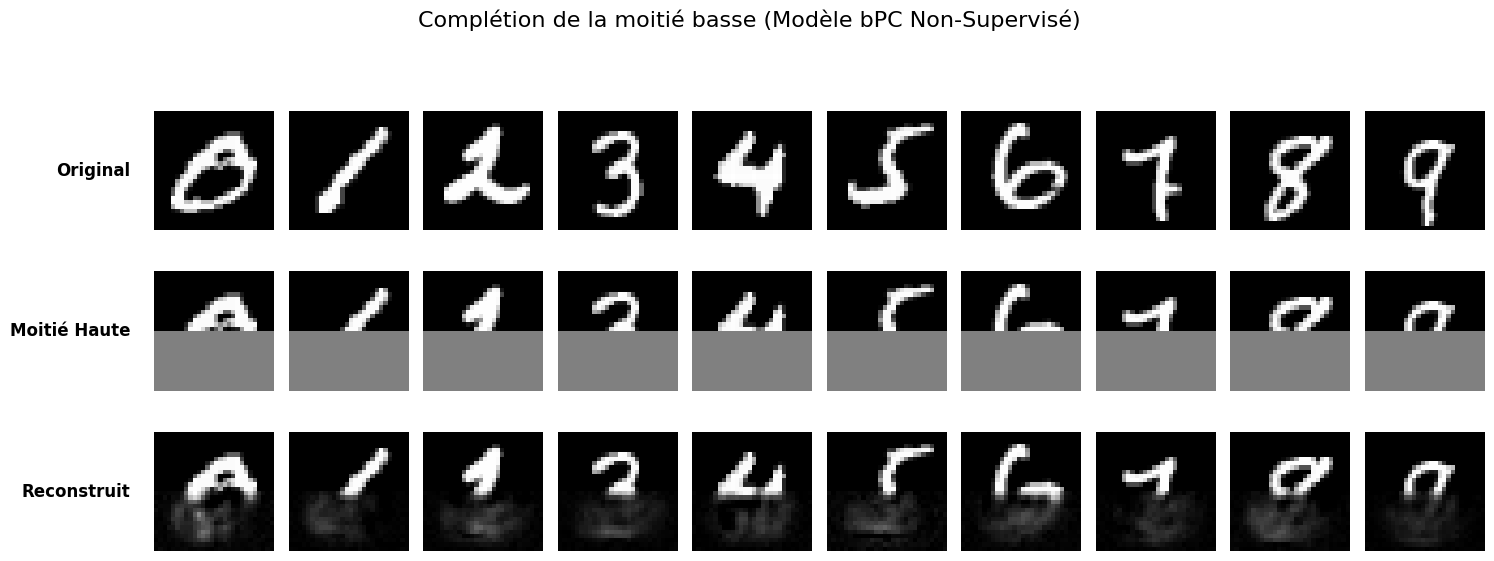

In [11]:
import torch
import matplotlib.pyplot as plt

model.eval()

# 1. Récupérer un exemple de chaque chiffre (de 0 à 9) du set de validation
examples = {}
for images, labels in valloader:
    for img, label in zip(images, labels):
        if label.item() not in examples:
            examples[label.item()] = img.view(784).to(device)
        if len(examples) == 10:
            break
    if len(examples) == 10:
        break

original_images = torch.stack([examples[i] for i in range(10)])

# ---------------------------------------------------------
# 2. NOUVEAU MASQUE : MOITIÉ BASSE OCCULTÉE
# ---------------------------------------------------------
# On crée un masque 2D de 28x28 initialisé à zéro
mask_2d = torch.zeros((28, 28), device=device)
# On met les 14 premières lignes (moitié haute) à 1
mask_2d[:14, :] = 1.0

# On aplatit le masque (784) et on l'étend pour tout le batch
known_mask = mask_2d.view(-1).unsqueeze(0).expand_as(original_images)
missing_mask = 1.0 - known_mask

# Application du masque (les pixels du bas deviennent 0)
occluded_images = original_images * known_mask

# 3. PRÉPARATION DE L'INFÉRENCE
x_init_comp = model.bottom_up_sweep(occluded_images)
x_comp = [t.clone().detach() for t in x_init_comp]

for i in range(model.L):
    x_comp[i].requires_grad = True

optimizer_comp = torch.optim.SGD(x_comp, lr=0.01)

# -----------------------------------------------------------------
# PHASE 1 : WARM-UP GÉNÉRATIF (Désactivation de l'énergie discriminative)
# -----------------------------------------------------------------
original_alpha_disc = model.alpha_disc
model.alpha_disc = 0.0  

print("Phase 1 : Remplissage génératif de la moitié basse...")
for _ in range(1000):
    optimizer_comp.zero_grad()
    energy = model.compute_energy(x_comp)
    energy.backward()
    
    # On n'applique le gradient que sur la moitié basse
    x_comp[0].grad.data *= missing_mask
    optimizer_comp.step()

# -----------------------------------------------------------------
# PHASE 2 : AFFINEMENT BIDIRECTIONNEL
# -----------------------------------------------------------------
model.alpha_disc = original_alpha_disc

print("Phase 2 : Affinement bidirectionnel...")
for _ in range(2000):
    optimizer_comp.zero_grad()
    energy = model.compute_energy(x_comp)
    energy.backward()
    
    x_comp[0].grad.data *= missing_mask
    optimizer_comp.step()

completed_images = x_comp[0].detach()

# ---------------------------------------------------------
# 4. AFFICHAGE DES RÉSULTATS
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 10, figsize=(15, 6))
fig.suptitle(f"Complétion de la moitié basse (Modèle bPC Non-Supervisé)", fontsize=16, y=0.98)

titles = ["Original", "Moitié Haute", "Reconstruit"]
tensors_to_plot = [original_images, occluded_images, completed_images]

for row in range(3):
    for col in range(10):
        # Repasser en 28x28 sur le CPU
        img = tensors_to_plot[row][col].cpu().numpy().reshape(28, 28)
        # Dénormaliser de [-1, 1] vers [0, 1]
        img_display = (img + 1) / 2.0  
        
        axes[row, col].imshow(img_display, cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
        
        # Ajouter le titre de ligne
        if col == 0:
            axes[row, col].text(-0.2, 0.5, titles[row], va='center', ha='right', 
                                transform=axes[row, col].transAxes, fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [12]:
import torch
import math

model.eval()
if 'linear_classifier' in locals():
    linear_classifier.eval()
else:
    print("Attention : Le linear_classifier n'est pas défini. Seule la RMSE sera calculée.")

total_comp_mse = 0
total_correct = 0
total_samples = 0

# ---------------------------------------------------------
# MASQUE GÉOMÉTRIQUE : Moitié basse (14 lignes) à 0
# ---------------------------------------------------------
mask_2d = torch.zeros((28, 28), device=device)
mask_2d[:14, :] = 1.0  # Moitié haute conservée
missing_ratio = 0.50   # 50% de l'image totale

print("Évaluation quantitative de la complétion (moitié basse) sur le set de Validation...")

max_steps_phase1 = 1000
max_steps_phase2 = 1000
epsilon = 1e-5

for images, labels in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # Application du masque sur tout le batch
    known_mask = mask_2d.view(-1).unsqueeze(0).expand_as(x1_input)
    missing_mask = 1.0 - known_mask
    occluded_images = x1_input * known_mask
    
    x_init_comp = model.bottom_up_sweep(occluded_images)
    x_comp = [t.clone().detach() for t in x_init_comp]
    
    for i in range(model.L):
        x_comp[i].requires_grad = True
        
    optimizer_comp = torch.optim.SGD(x_comp, lr=0.01)
    
    # -----------------------------------------------------------------
    # PHASE 1 : WARM-UP GÉNÉRATIF
    # -----------------------------------------------------------------
    original_alpha_disc = model.alpha_disc
    model.alpha_disc = 0.0  
    
    prev_energy = float('inf')
    for step in range(max_steps_phase1):
        optimizer_comp.zero_grad()
        energy = model.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask
        optimizer_comp.step()
        
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    # -----------------------------------------------------------------
    # PHASE 2 : AFFINEMENT BIDIRECTIONNEL
    # -----------------------------------------------------------------
    model.alpha_disc = original_alpha_disc
    
    prev_energy = float('inf')
    for step in range(max_steps_phase2):
        optimizer_comp.zero_grad()
        energy = model.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask
        optimizer_comp.step()
        
        current_energy = energy.item()
        if abs(prev_energy - current_energy) < epsilon:
            break
        prev_energy = current_energy
        
    completed_images = x_comp[0].detach()
    latent_representations = x_comp[-1].detach()
    
    # ---------------------------------------------------------
    # CALCUL DES MÉTRIQUES
    # ---------------------------------------------------------
    # 1. RMSE Physique (uniquement sur la moitié basse)
    diff_comp = (completed_images - x1_input) * missing_mask
    total_comp_mse += torch.sum(diff_comp ** 2).item()
    
    # 2. Précision Sémantique
    if 'linear_classifier' in locals():
        with torch.no_grad():
            outputs = linear_classifier(latent_representations)
            predictions = torch.argmax(outputs, dim=1)
            total_correct += (predictions == labels).sum().item()
            
    total_samples += batch_size

# Affichage des résultats finaux
rmse_completion = math.sqrt(total_comp_mse / (total_samples * 784 * missing_ratio))
print(f"-> RMSE de Complétion (moitié basse) : {rmse_completion:.4f}")

if 'linear_classifier' in locals():
    accuracy = 100 * total_correct / total_samples
    print(f"-> Précision de classification après complétion : {accuracy:.2f}%")

Attention : Le linear_classifier n'est pas défini. Seule la RMSE sera calculée.
Évaluation quantitative de la complétion (moitié basse) sur le set de Validation...
-> RMSE de Complétion (moitié basse) : 0.5386


Extraction des représentations latentes par classe...
Ajustement des distributions gaussiennes multivariées...
Génération des images...


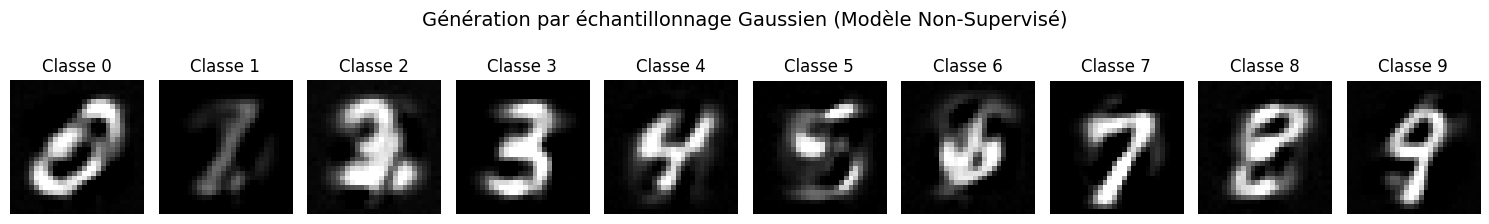

In [13]:
import torch
import matplotlib.pyplot as plt
from torch.distributions.multivariate_normal import MultivariateNormal

model.eval()

# 1. EXTRACTION DES REPRÉSENTATIONS LATENTES SUR LE SET D'ENTRAÎNEMENT
print("Extraction des représentations latentes par classe...")
latent_vectors = {i: [] for i in range(10)}

# Pour gagner du temps, on peut extraire sur un sous-ensemble (ex: 5000 images)
subset_size = 0
for images, labels in trainloader:
    x1_input = images.view(images.size(0), -1).to(device)
    
    # Encodage (Inférence bottom-up)
    x_init_enc = model.bottom_up_sweep(x1_input)
    x_enc = [t.clone().detach() for t in x_init_enc]
    for i in range(1, model.L):
        x_enc[i].requires_grad = True
        
    optimizer_enc = torch.optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
    
    # 100 étapes suffisent généralement pour obtenir une bonne approximation latente
    for _ in range(100):
        optimizer_enc.zero_grad()
        energy = model.compute_energy(x_enc)
        energy.backward()
        optimizer_enc.step()
        
    latent_batch = x_enc[-1].detach()
    
    # Tri par classe
    for i in range(len(labels)):
        label = labels[i].item()
        latent_vectors[label].append(latent_batch[i])
        
    subset_size += images.size(0)
    if subset_size >= 5000: # Limite pour l'exemple
        break

# 2. CALCUL DES MOYENNES ET COVARIANCES PAR CLASSE
print("Ajustement des distributions gaussiennes multivariées...")
gaussians = {}

for label in range(10):
    # Regroupement des tenseurs d'une même classe
    Z_c = torch.stack(latent_vectors[label])
    
    # Calcul de la moyenne empirique (mu)
    mu_c = torch.mean(Z_c, dim=0)
    
    # Calcul de la matrice de covariance (Sigma)
    # torch.cov attend les variables en lignes et les observations en colonnes, d'où le .T
    cov_c = torch.cov(Z_c.T)
    
    # Astuce numérique : ajout d'une infime valeur sur la diagonale pour garantir 
    # que la matrice est définie positive (évite les erreurs de singularité)
    cov_c += torch.eye(cov_c.size(0), device=device) * 1e-5
    
    gaussians[label] = MultivariateNormal(mu_c, cov_c)

# 3. ÉCHANTILLONNAGE ET GÉNÉRATION D'IMAGES
print("Génération des images...")
generated_images = []

for label in range(10):
    # On tire un échantillon (vecteur de taille 30) depuis la gaussienne de la classe
    z_sample = gaussians[label].sample().unsqueeze(0)
    
    # Initialisation top-down depuis cet échantillon
    x_init_dec = model.top_down_sweep(z_sample)
    x_dec = [t.clone().detach() for t in x_init_dec]
    
    # Inférence générative (on fige la couche latente, on infère le reste)
    for i in range(model.L - 1):
        x_dec[i].requires_grad = True
        
    optimizer_dec = torch.optim.SGD([x_dec[i] for i in range(model.L - 1)], lr=0.01)
    
    for _ in range(200): # Inférence descendante
        optimizer_dec.zero_grad()
        energy = model.compute_energy(x_dec)
        energy.backward()
        optimizer_dec.step()
        
    generated_images.append(x_dec[0].detach().cpu().numpy().reshape(28, 28))

# 4. AFFICHAGE DES RÉSULTATS
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
fig.suptitle("Génération par échantillonnage Gaussien (Modèle Non-Supervisé)", fontsize=14, y=1.1)

for i in range(10):
    # Dénormalisation de [-1, 1] vers [0, 1] pour l'affichage
    img_display = (generated_images[i] + 1) / 2.0 
    axes[i].imshow(img_display, cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    axes[i].set_title(f"Classe {i}")

plt.tight_layout()
plt.show()

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

model.eval()

# ---------------------------------------------------------
# 1. EXTRACTION DES REPRÉSENTATIONS LATENTES
# ---------------------------------------------------------
print("Extraction des représentations latentes (Train et Validation)...")

def extract_latents(dataloader, max_batches=None):
    latents = []
    all_labels = []
    batches_processed = 0
    
    for images, labels in dataloader:
        x1_input = images.view(images.size(0), -1).to(device)
        
        # Encodage (Inférence bottom-up)
        x_init_enc = model.bottom_up_sweep(x1_input)
        x_enc = [t.clone().detach() for t in x_init_enc]
        
        # Figer l'entrée et libérer le reste
        for i in range(1, model.L):
            x_enc[i].requires_grad = True
            
        optimizer_enc = optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
        
        # Inférence de 100 étapes (comme spécifié dans l'article pour l'extraction)
        for _ in range(100):
            optimizer_enc.zero_grad()
            energy = model.compute_energy(x_enc)
            energy.backward()
            optimizer_enc.step()
            
        latents.append(x_enc[-1].detach())
        all_labels.append(labels.to(device))
        
        batches_processed += 1
        if max_batches and batches_processed >= max_batches:
            break
            
    return torch.cat(latents), torch.cat(all_labels)

# Extraction (pour limiter le temps d'exécution dans le notebook, on extrait tout)
X_train_latent, y_train = extract_latents(trainloader)
X_val_latent, y_val = extract_latents(valloader)

# ---------------------------------------------------------
# 2. ENTRAÎNEMENT DU CLASSIFIEUR LINÉAIRE (LINEAR READOUT)
# ---------------------------------------------------------
print("Entraînement du classifieur linéaire sur l'espace latent...")

# Le classifieur ne contient qu'une seule matrice de poids : 30 -> 10
linear_classifier = nn.Linear(30, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(linear_classifier.parameters(), lr=0.01)

# Création d'un DataLoader pour l'entraînement rapide du classifieur
train_latent_dataset = torch.utils.data.TensorDataset(X_train_latent, y_train)
train_latent_loader = torch.utils.data.DataLoader(train_latent_dataset, batch_size=256, shuffle=True)

epochs_clf = 50
for epoch in range(epochs_clf):
    linear_classifier.train()
    for inputs, targets in train_latent_loader:
        optimizer_clf.zero_grad()
        outputs = linear_classifier(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_clf.step()

# ---------------------------------------------------------
# 3. ÉVALUATION DE LA PRÉCISION (ACCURACY)
# ---------------------------------------------------------
linear_classifier.eval()
with torch.no_grad():
    outputs_val = linear_classifier(X_val_latent)
    predictions = torch.argmax(outputs_val, dim=1)
    correct = (predictions == y_val).sum().item()
    total = y_val.size(0)

accuracy = 100 * correct / total
print(f"-> Précision de classification (Linear Readout) : {accuracy:.2f}%")

Extraction des représentations latentes (Train et Validation)...
Entraînement du classifieur linéaire sur l'espace latent...
-> Précision de classification (Linear Readout) : 87.29%


In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. DÉFINITION DU MODÈLE MIXTE
# ---------------------------------------------------------
class MixedBidirectionalPC(nn.Module):
    def __init__(self, layer_sizes=[784, 450, 30], alpha_gen=1e-4, alpha_disc=1.0, num_labels=10):
        super().__init__()
        self.L = len(layer_sizes)
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        self.V = nn.ModuleList([nn.Linear(layer_sizes[i], layer_sizes[i+1]) for i in range(self.L - 1)])
        self.W = nn.ModuleList([nn.Linear(layer_sizes[i+1], layer_sizes[i]) for i in range(self.L - 1)])
        self.activation = nn.LeakyReLU()

        # Ajustement des alphas selon le papier bPC pour les tâches mixtes
        alpha_disc_L_mixed = torch.ones(layer_sizes[-1]) * alpha_disc
        alpha_disc_L_mixed[num_labels:] = alpha_gen  # Les neurones libres égalent alpha_gen
        self.register_buffer('alpha_disc_L', alpha_disc_L_mixed)

    def compute_energy(self, x):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen = self.W[i](self.activation(x[i+1]))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2) * (self.alpha_gen / 2)
            
            pred_disc = self.V[i](self.activation(x[i]))
            diff_sq_disc = (x[i+1] - pred_disc) ** 2
            
            if i == self.L - 2:
                energy_disc += torch.sum(diff_sq_disc * self.alpha_disc_L) / 2
            else:
                energy_disc += torch.sum(diff_sq_disc) * (self.alpha_disc / 2)
                
        return energy_gen + energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.V[i](self.activation(x[-1])))
        return x

    def top_down_sweep(self, xL):
        x = [None] * self.L
        x[-1] = xL.clone()
        with torch.no_grad():
            for i in range(self.L - 2, -1, -1):
                x[i] = self.W[i](self.activation(x[i+1]))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01, partial_clamp=None):
        x = [t.clone() for t in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            for _ in range(steps):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x)
                energy.backward()
                
                if partial_clamp is not None:
                    layer_idx, mask = partial_clamp
                    if x[layer_idx].requires_grad:
                        x[layer_idx].grad.data *= (1.0 - mask)
                
                optimizer_x.step()
                
        return [t.detach() for t in x]

# ---------------------------------------------------------
# 2. ENTRAÎNEMENT DU MODÈLE MIXTE
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mixed = MixedBidirectionalPC(layer_sizes=[784, 450, 30], alpha_gen=1e-4, alpha_disc=1.0).to(device)
optimizer_theta_mixed = optim.AdamW(model_mixed.parameters(), lr=1e-4, weight_decay=5e-3)

latent_mask_mixed = torch.zeros(30, device=device)
latent_mask_mixed[:10] = 1.0  # Masque pour figer uniquement les 10 labels

epochs_mixed = 25
print("Début de l'entraînement du modèle mixte...")

for epoch in range(epochs_mixed):
    model_mixed.train()
    total_energy_mixed = 0
    
    for images, labels in trainloader:
        x1_input = images.view(images.size(0), -1).to(device)
        batch_size = x1_input.size(0)
        
        xL_label = torch.zeros((batch_size, 30), device=device)
        xL_label[:, :10] = torch.nn.functional.one_hot(labels, num_classes=10).float()
        
        x_init = model_mixed.bottom_up_sweep(x1_input)
        x_init[0] = x1_input
        x_init[-1][:, :10] = xL_label[:, :10]
        
        # Clampage partiel sur la couche 2 (indice 2)
        x_inferred = model_mixed.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, partial_clamp=(2, latent_mask_mixed.unsqueeze(0)))
        
        optimizer_theta_mixed.zero_grad()
        loss = model_mixed.compute_energy(x_inferred)
        loss.backward()
        optimizer_theta_mixed.step()
        
        total_energy_mixed += loss.item()

print("Entraînement terminé.")

# ---------------------------------------------------------
# 3. TEST 1 : DÉCODEUR LINÉAIRE (Précision)
# ---------------------------------------------------------
model_mixed.eval()
print("\nExtraction des latents mixtes et entraînement du Readout Linéaire...")

def extract_latents_mixed(dataloader):
    latents = []
    all_labels = []
    for images, labels in dataloader:
        x1_input = images.view(images.size(0), -1).to(device)
        x_init_enc = model_mixed.bottom_up_sweep(x1_input)
        x_enc = [t.clone().detach() for t in x_init_enc]
        
        for i in range(1, model_mixed.L):
            x_enc[i].requires_grad = True
            
        optimizer_enc = optim.SGD([x_enc[i] for i in range(1, model_mixed.L)], lr=0.01)
        for _ in range(100):
            optimizer_enc.zero_grad()
            energy = model_mixed.compute_energy(x_enc)
            energy.backward()
            optimizer_enc.step()
            
        latents.append(x_enc[-1].detach())
        all_labels.append(labels.to(device))
    return torch.cat(latents), torch.cat(all_labels)

X_train_latent_mixed, y_train_mixed = extract_latents_mixed(trainloader)
X_val_latent_mixed, y_val_mixed = extract_latents_mixed(valloader)

linear_classifier_mixed = nn.Linear(30, 10).to(device)
criterion_mixed = nn.CrossEntropyLoss()
optimizer_clf_mixed = optim.Adam(linear_classifier_mixed.parameters(), lr=0.01)

train_latent_loader_mixed = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X_train_latent_mixed, y_train_mixed), 
    batch_size=256, shuffle=True
)

for epoch in range(50):
    linear_classifier_mixed.train()
    for inputs, targets in train_latent_loader_mixed:
        optimizer_clf_mixed.zero_grad()
        outputs = linear_classifier_mixed(inputs)
        loss = criterion_mixed(outputs, targets)
        loss.backward()
        optimizer_clf_mixed.step()

linear_classifier_mixed.eval()
with torch.no_grad():
    predictions_mixed = torch.argmax(linear_classifier_mixed(X_val_latent_mixed), dim=1)
    acc_mixed = 100 * (predictions_mixed == y_val_mixed).sum().item() / y_val_mixed.size(0)
print(f"-> Précision du classifieur sur espace mixte : {acc_mixed:.2f}%")

# ---------------------------------------------------------
# 4. TEST 2 : RECONSTRUCTION (RMSE)
# ---------------------------------------------------------
print("\nÉvaluation de la reconstruction mixte...")
total_recon_mse_mixed = 0
total_samples_mixed = 0
epsilon_mixed = 1e-5

for images, _ in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    batch_size = x1_input.size(0)
    
    # Encodage
    x_init_enc = model_mixed.bottom_up_sweep(x1_input)
    x_enc = [t.clone().detach() for t in x_init_enc]
    for i in range(1, model_mixed.L):
        x_enc[i].requires_grad = True
    optimizer_enc = optim.SGD([x_enc[i] for i in range(1, model_mixed.L)], lr=0.01)
    
    prev_energy = float('inf')
    for _ in range(1000):
        optimizer_enc.zero_grad()
        energy = model_mixed.compute_energy(x_enc)
        energy.backward()
        optimizer_enc.step()
        if abs(prev_energy - energy.item()) < epsilon_mixed: break
        prev_energy = energy.item()
        
    # Décodage
    x_init_dec = model_mixed.top_down_sweep(x_enc[-1].detach())
    x_dec = [t.clone().detach() for t in x_init_dec]
    for i in range(model_mixed.L - 1):
        x_dec[i].requires_grad = True
    optimizer_dec = optim.SGD([x_dec[i] for i in range(model_mixed.L - 1)], lr=0.01)
    
    prev_energy = float('inf')
    for _ in range(1000):
        optimizer_dec.zero_grad()
        energy = model_mixed.compute_energy(x_dec)
        energy.backward()
        optimizer_dec.step()
        if abs(prev_energy - energy.item()) < epsilon_mixed: break
        prev_energy = energy.item()
        
    total_recon_mse_mixed += torch.sum((x_dec[0].detach() - x1_input) ** 2).item()
    total_samples_mixed += batch_size

rmse_recon_mixed = math.sqrt(total_recon_mse_mixed / (total_samples_mixed * 784))
print(f"-> RMSE de Reconstruction mixte : {rmse_recon_mixed:.4f}")

# ---------------------------------------------------------
# 5. TEST 3 : COMPLÉTION (Moitié Basse + RMSE + Précision)
# ---------------------------------------------------------
print("\nÉvaluation de la complétion mixte (moitié basse)...")
total_comp_mse_mixed = 0
total_correct_comp_mixed = 0

mask_2d_mixed = torch.zeros((28, 28), device=device)
mask_2d_mixed[:14, :] = 1.0
missing_ratio_mixed = 0.50

for images, labels in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    
    known_mask = mask_2d_mixed.view(-1).unsqueeze(0).expand_as(x1_input)
    missing_mask = 1.0 - known_mask
    occluded_images = x1_input * known_mask
    
    x_init_comp = model_mixed.bottom_up_sweep(occluded_images)
    x_comp = [t.clone().detach() for t in x_init_comp]
    for i in range(model_mixed.L):
        x_comp[i].requires_grad = True
        
    optimizer_comp = optim.SGD(x_comp, lr=0.01)
    
    # Phase 1: Désactivation temporaire de alpha_disc
    orig_alpha_disc = model_mixed.alpha_disc
    orig_alpha_disc_L = model_mixed.alpha_disc_L.clone()
    
    model_mixed.alpha_disc = 0.0
    model_mixed.alpha_disc_L = torch.zeros_like(orig_alpha_disc_L)
    
    prev_energy = float('inf')
    for _ in range(1000):
        optimizer_comp.zero_grad()
        energy = model_mixed.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask
        optimizer_comp.step()
        if abs(prev_energy - energy.item()) < epsilon_mixed: break
        prev_energy = energy.item()
        
    # Phase 2: Réactivation de alpha_disc
    model_mixed.alpha_disc = orig_alpha_disc
    model_mixed.alpha_disc_L = orig_alpha_disc_L
    
    prev_energy = float('inf')
    for _ in range(1000):
        optimizer_comp.zero_grad()
        energy = model_mixed.compute_energy(x_comp)
        energy.backward()
        x_comp[0].grad.data *= missing_mask
        optimizer_comp.step()
        if abs(prev_energy - energy.item()) < epsilon_mixed: break
        prev_energy = energy.item()
        
    completed_images = x_comp[0].detach()
    latents_comp = x_comp[-1].detach()
    
    diff_comp = (completed_images - x1_input) * missing_mask
    total_comp_mse_mixed += torch.sum(diff_comp ** 2).item()
    
    with torch.no_grad():
        preds = torch.argmax(linear_classifier_mixed(latents_comp), dim=1)
        total_correct_comp_mixed += (preds == labels).sum().item()

rmse_comp_mixed = math.sqrt(total_comp_mse_mixed / (total_samples_mixed * 784 * missing_ratio_mixed))
acc_comp_mixed = 100 * total_correct_comp_mixed / total_samples_mixed

print(f"-> RMSE de Complétion mixte : {rmse_comp_mixed:.4f}")
print(f"-> Précision après complétion : {acc_comp_mixed:.2f}%")

Début de l'entraînement du modèle mixte...
Entraînement terminé.

Extraction des latents mixtes et entraînement du Readout Linéaire...
-> Précision du classifieur sur espace mixte : 97.81%

Évaluation de la reconstruction mixte...
-> RMSE de Reconstruction mixte : 0.5018

Évaluation de la complétion mixte (moitié basse)...
-> RMSE de Complétion mixte : 0.9597
-> Précision après complétion : 69.00%


In [16]:
import torch

# S'assurer que le modèle mixte est en mode évaluation
model_mixed.eval()

correct_native = 0
total_native = 0

print("Évaluation de la performance du classifieur intégré (Modèle Mixte) sur le set de Validation...")

for images, labels in valloader:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # 1. Initialisation rapide de bas en haut (Inférence amortie)
    x_init_class = model_mixed.bottom_up_sweep(x1_input)
    
    # 2. Inférence discriminative (T_eval = 100 étapes comme spécifié dans le papier)
    # On fige UNIQUEMENT l'image d'entrée (indice 0). 
    # Les 30 neurones du haut (y compris les 10 neurones de label) sont libres de converger.
    x_res_class = model_mixed.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # 3. Extraction des activations de la couche supérieure (x_L)
    latent_output = x_res_class[-1]
    
    # On isole les 10 premiers neurones qui agissent comme le classifieur natif du modèle
    native_logits = latent_output[:, :10]
    
    # Détermination de la classe (Argmax sur l'activité neuronale la plus forte)
    predicted_classes = torch.argmax(native_logits, dim=1)
    
    # Décompte des bonnes réponses
    correct_native += (predicted_classes == labels).sum().item()
    total_native += batch_size

# Calcul de la précision finale
accuracy_native = 100 * correct_native / total_native
print(f"-> Précision de classification native (Sans Readout externe) : {accuracy_native:.2f}%")

Évaluation de la performance du classifieur intégré (Modèle Mixte) sur le set de Validation...
-> Précision de classification native (Sans Readout externe) : 97.37%


Récupération des données...
Extraction des activations pour le modèle 100% Non-Supervisé...
Extraction des activations pour le modèle Mixte...
Calcul de t-SNE en cours (cela peut prendre une minute)...


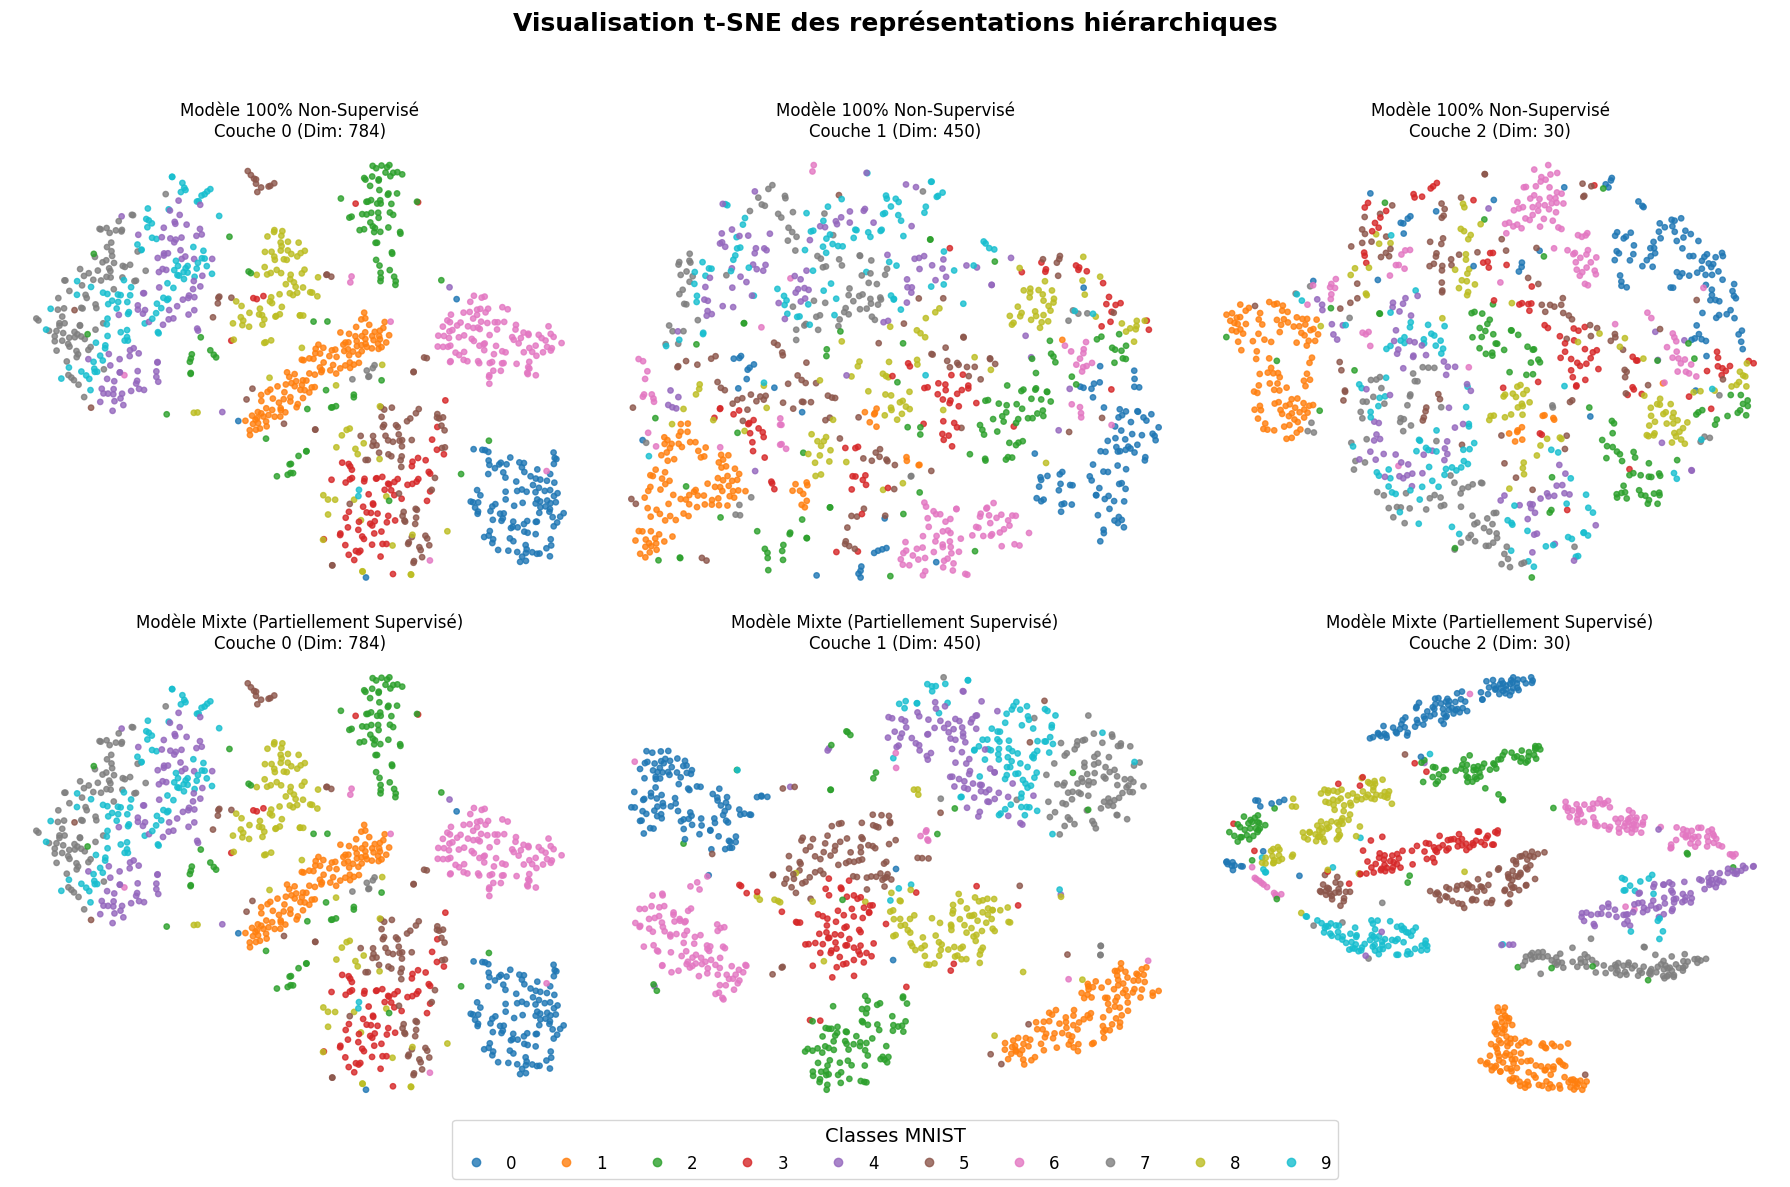

In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# S'assurer que les deux modèles sont en mode évaluation
model.eval()
model_mixed.eval()

# ---------------------------------------------------------
# 1. RÉCUPÉRATION D'UN SOUS-ENSEMBLE DE DONNÉES (1000 images)
# ---------------------------------------------------------
print("Récupération des données...")
images_subset = []
labels_subset = []
num_samples = 1000

for images, labels in valloader:
    images_subset.append(images.view(images.size(0), -1))
    labels_subset.append(labels)
    if sum(t.size(0) for t in images_subset) >= num_samples:
        break

x_inputs = torch.cat(images_subset)[:num_samples].to(device)
y_targets = torch.cat(labels_subset)[:num_samples].numpy()

# ---------------------------------------------------------
# 2. FONCTION D'EXTRACTION DES COUCHES
# ---------------------------------------------------------
def extract_all_layers(net, inputs):
    """
    Fait converger le réseau sur l'entrée et retourne l'activité des 3 couches.
    """
    x_init = net.bottom_up_sweep(inputs)
    x_infer = [t.clone().detach() for t in x_init]
    
    # On fige l'entrée (couche 0) et on libère les couches supérieures
    for i in range(1, net.L):
        x_infer[i].requires_grad = True
        
    optimizer = torch.optim.SGD([x_infer[i] for i in range(1, net.L)], lr=0.01)
    
    # Inférence pour atteindre l'équilibre (100 étapes)
    for _ in range(100):
        optimizer.zero_grad()
        energy = net.compute_energy(x_infer)
        energy.backward()
        optimizer.step()
        
    return [t.detach().cpu().numpy() for t in x_infer]

print("Extraction des activations pour le modèle 100% Non-Supervisé...")
acts_unsup = extract_all_layers(model, x_inputs)

print("Extraction des activations pour le modèle Mixte...")
acts_mixed = extract_all_layers(model_mixed, x_inputs)

# ---------------------------------------------------------
# 3. CALCUL T-SNE ET AFFICHAGE
# ---------------------------------------------------------
print("Calcul de t-SNE en cours (cela peut prendre une minute)...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Visualisation t-SNE des représentations hiérarchiques", fontsize=18, fontweight='bold')

model_names = ["Modèle 100% Non-Supervisé", "Modèle Mixte (Partiellement Supervisé)"]
activations = [acts_unsup, acts_mixed]

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        layer_data = activations[row][col]
        
        # Application de t-SNE
        tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
        z_tsne = tsne.fit_transform(layer_data)
        
        # Affichage du nuage de points coloré par classe
        scatter = ax.scatter(z_tsne[:, 0], z_tsne[:, 1], c=y_targets, cmap='tab10', s=15, alpha=0.8)
        
        ax.set_title(f"{model_names[row]}\nCouche {col} (Dim: {layer_data.shape[1]})", fontsize=12)
        ax.axis('off')

# Ajout d'une légende commune en bas
handles, labels = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes MNIST", fontsize=12, title_fontsize=14)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalisation standardisée sur [-1, 1]
transform_1d = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
transform_3d = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# ---------------------------------------------------------
# FASHION-MNIST (Exemple avec 30 000 images au lieu de 60 000)
# ---------------------------------------------------------
fmnist_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_1d)

# On sélectionne uniquement les 30 000 premiers indices
fmnist_subset = Subset(fmnist_full, range(30000))

# Séparation sur ce nouveau sous-ensemble (ex: 25k train, 5k validation)
fmnist_train, fmnist_val = random_split(fmnist_subset, [25000, 5000])

fmnist_trainloader = torch.utils.data.DataLoader(fmnist_train, batch_size=512, shuffle=True)
fmnist_valloader = torch.utils.data.DataLoader(fmnist_val, batch_size=512, shuffle=False)

# ---------------------------------------------------------
# CIFAR-10 (Limité à 30 000 images au lieu de 50 000)
# ---------------------------------------------------------
cifar_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_3d)

# On sélectionne uniquement les 30 000 premiers indices
cifar_subset = Subset(cifar_full, range(30000))

# Séparation sur ce nouveau sous-ensemble (ex: 25k train, 5k validation)
cifar_train, cifar_val = random_split(cifar_subset, [25000, 5000])

cifar_trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=256, shuffle=True)
cifar_valloader = torch.utils.data.DataLoader(cifar_val, batch_size=256, shuffle=False)

# ---------------------------------------------------------
# DICTIONNAIRE DES DATASETS
# ---------------------------------------------------------
datasets = {
    "fMNIST": {"train": fmnist_trainloader, "val": fmnist_valloader, "input_dim": 784, "shape": (1, 28, 28)},
    "CIFAR10": {"train": cifar_trainloader, "val": cifar_valloader, "input_dim": 3072, "shape": (3, 32, 32)}
}

print("Datasets chargés et réduits avec succès !")
#print(f"Taille de l'entraînement CIFAR-10 : {len(cifar_train)} images")
#print(f"Taille de la validation CIFAR-10  : {len(cifar_val)} images")

Datasets chargés et réduits avec succès !


In [4]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader

# LE DÉTAIL QUI SAUVE L'ARCHITECTURE : transforms.Pad(2)
transform_fmnist_padded = transforms.Compose([
    transforms.Pad(2), # Ajoute 2 pixels de bordure (28x28 -> 32x32)
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

print("Rechargement de Fashion-MNIST avec Padding (32x32)...")

# Application de la nouvelle transformation
fmnist_full_padded = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_fmnist_padded)

# On refait la séparation Train/Val (ou Subset si tu avais limité à 30k)
fmnist_train, fmnist_val = random_split(fmnist_full_padded, [50000, 10000])

# Mise à jour stricte de ton dictionnaire de datasets
datasets["fMNIST"]["train"] = DataLoader(fmnist_train, batch_size=1024, shuffle=True)
datasets["fMNIST"]["val"] = DataLoader(fmnist_val, batch_size=1024, shuffle=False)

# Vérification
sample_images, _ = next(iter(datasets["fMNIST"]["train"]))
print(f"Nouvelle taille des images : {sample_images.shape} (Attendu: Batch x 1 x 32 x 32)")

Rechargement de Fashion-MNIST avec Padding (32x32)...
Nouvelle taille des images : torch.Size([1024, 1, 32, 32]) (Attendu: Batch x 1 x 32 x 32)


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------------------------------------------------
# MODULES DE BATCHNORM FREEZING (Adaptés pour les CNNs)
# ---------------------------------------------------------
class BatchNormFreezing1d(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.bn = nn.BatchNorm1d(num_features)
        self.freeze_stats = False

    def forward(self, x):
        if self.freeze_stats and self.training:
            return F.batch_norm(x, running_mean=None, running_var=None, 
                                weight=self.bn.weight, bias=self.bn.bias, training=True)
        return self.bn(x)

class BatchNormFreezing2d(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features)
        self.freeze_stats = False

    def forward(self, x):
        if self.freeze_stats and self.training:
            return F.batch_norm(x, running_mean=None, running_var=None, 
                                weight=self.bn.weight, bias=self.bn.bias, training=True)
        return self.bn(x)

# ---------------------------------------------------------
# ARCHITECTURE VGG5
# ---------------------------------------------------------
class VGG5SupervisedBiPC(nn.Module):
    def __init__(self, alpha_gen=1e-4, alpha_disc=1.0):
        super().__init__()
        self.L = 6 # 5 couches de transformation + 1 entrée = 6 niveaux d'états
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        # ---------------------------------------------------------
        # VOIE ASCENDANTE (V) : 1 canal en entrée
        # ---------------------------------------------------------
        self.V = nn.ModuleList([
            nn.Sequential(nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1), nn.MaxPool2d(2, 2)),
            nn.Sequential(nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nn.MaxPool2d(2, 2)),
            nn.Sequential(nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1), nn.MaxPool2d(2, 2)),
            nn.Sequential(nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=0), nn.MaxPool2d(2, 2)),
            nn.Sequential(nn.Flatten(), nn.Linear(512, 10))
        ])

        # ---------------------------------------------------------
        # VOIE DESCENDANTE (W) : 1 canal en sortie
        # ---------------------------------------------------------
        self.W = nn.ModuleList([
            nn.Sequential(nn.Upsample(scale_factor=2), nn.ConvTranspose2d(128, 1, kernel_size=3, stride=1, padding=1)),
            nn.Sequential(nn.Upsample(scale_factor=2), nn.ConvTranspose2d(256, 128, kernel_size=3, stride=1, padding=1)),
            nn.Sequential(nn.Upsample(scale_factor=2), nn.ConvTranspose2d(512, 256, kernel_size=3, stride=1, padding=1)),
            # Attention ici : padding=0 et sortie sur 4x4 (pas d'upsample immédiat car le maxpool précédent réduit 4x4 à 2x2)
            nn.Sequential(nn.Upsample(scale_factor=2), nn.ConvTranspose2d(512, 512, kernel_size=3, stride=1, padding=0)),
            nn.Sequential(nn.Linear(10, 512), nn.Unflatten(1, (512, 1, 1)))
        ])

        self.activation = nn.LeakyReLU()

        # ---------------------------------------------------------
        # BATCHNORM FREEZING POUR LA VOIE ASCENDANTE (Discriminative)
        # ---------------------------------------------------------
        # Les sorties de V sont successivement : 128, 256, 512, 512 (en 2D), puis 10 (en 1D)
        self.bns_disc = nn.ModuleList([
            BatchNormFreezing2d(128),
            BatchNormFreezing2d(256),
            BatchNormFreezing2d(512),
            BatchNormFreezing2d(512),
            BatchNormFreezing1d(10)
        ])

        # ---------------------------------------------------------
        # BATCHNORM FREEZING POUR LA VOIE DESCENDANTE (Générative)
        # ---------------------------------------------------------
        # Les sorties de W (qui prédisent x_0, x_1, x_2, x_3, x_4) sont toutes des images/features 2D.
        # Elles ont pour canaux : 1 (image), 128, 256, 512, 512.
        self.bns_gen = nn.ModuleList([
            BatchNormFreezing2d(1),
            BatchNormFreezing2d(128),
            BatchNormFreezing2d(256),
            BatchNormFreezing2d(512),
            BatchNormFreezing2d(512)  # Le Unflatten sort bien un tenseur 2D de 512 canaux
        ])

    def set_bn_freezing(self, state: bool):
        for bn in self.bns_gen: bn.freeze_stats = state
        for bn in self.bns_disc: bn.freeze_stats = state

    # ---------------------------------------------------------
    # ÉNERGIE ET INFÉRENCE (Avec Spiking Precision et Forward Updates)
    # ---------------------------------------------------------
    def compute_energy(self, x, t=None, lr_x=0.01):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            sigma = 1.0
            if t is not None and (i + 1) == (self.L - 1) - t:
                sigma = lr_x  # Spiking Precision
            
            # Application du BatchNorm Freezing sur les prédictions
            pred_gen = self.bns_gen[i](self.W[i](self.activation(x[i+1])))
            energy_gen += torch.sum((x[i] - pred_gen) ** 2) * (self.alpha_gen / (2 * sigma))
            
            pred_disc = self.bns_disc[i](self.V[i](self.activation(x[i])))
            energy_disc += torch.sum((x[i+1] - pred_disc) ** 2) * (self.alpha_disc / (2 * sigma))
            
        return energy_gen + energy_disc

    def compute_forward_update_energy(self, x_T, x_init):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen_0 = self.bns_gen[i](self.W[i](self.activation(x_init[i+1].detach())))
            energy_gen += torch.sum((x_T[i].detach() - pred_gen_0) ** 2) * (self.alpha_gen / 2)
            
            pred_disc_0 = self.bns_disc[i](self.V[i](self.activation(x_init[i].detach())))
            energy_disc += torch.sum((x_T[i+1].detach() - pred_disc_0) ** 2) * (self.alpha_disc / 2)
        return energy_gen + energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.bns_disc[i](self.V[i](self.activation(x[-1]))))
        return x

    def infer(self, x_init, clamped_indices, steps=100, lr_x=0.01):
        x = [tensor.clone() for tensor in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            self.set_bn_freezing(True)
            for step in range(1, steps + 1):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x, t=step, lr_x=lr_x)
                energy.backward()
                optimizer_x.step()
            self.set_bn_freezing(False)
        return [tensor.detach() for tensor in x]
# ---------------------------------------------------------
# 2. ENTRAÎNEMENT SUR CIFAR-10
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vgg5_fmnist = VGG5SupervisedBiPC( alpha_gen=1e-4, alpha_disc=1.0).to(device)
optimizer_sup = optim.AdamW(vgg5_fmnist.parameters(), lr=1e-4, weight_decay=5e-3)

epochs_sup = 5
print("Début de l'entraînement du modèle 100% Supervisé sur CIFAR-10...")

for epoch in range(epochs_sup):
    vgg5_fmnist.train()
    total_energy_sup = 0
    
    # On utilise le cifar_trainloader généré dans la cellule précédente (réduit à 25k)
    for images, labels in datasets["fMNIST"]["train"]:
        x1_input = images.to(device)
        xL_label = torch.nn.functional.one_hot(labels, num_classes=10).float().to(device)
        
        # 1. On sauvegarde précieusement les états initiaux (mu_0)
        x_init = vgg5_fmnist.bottom_up_sweep(x1_input)
        
        # [Fixation des labels si besoin, ex: x_init[-1] = labels]
        
        # 2. Inférence (les neurones convergent vers x_T)
        x_inferred = vgg5_fmnist.infer(x_init, clamped_indices=[0, 5], steps=7)
        
        # 3. MISE À JOUR DES POIDS (Forward Updates)
        optimizer_sup.zero_grad()
        # On utilise la nouvelle fonction d'énergie qui croise x_inferred et x_init
        loss = vgg5_fmnist.compute_forward_update_energy(x_T=x_inferred, x_init=x_init)
        loss.backward()
        optimizer_sup.step()
        
        total_energy_sup += loss.item()

    print(f"Epoch {epoch+1}/{epochs_sup} | Énergie : {total_energy_sup/len(datasets['fMNIST']['train']):.4f}")

Début de l'entraînement du modèle 100% Supervisé sur CIFAR-10...
Epoch 1/5 | Énergie : 2008.4970
Epoch 2/5 | Énergie : 1040.6071
Epoch 3/5 | Énergie : 850.5941
Epoch 4/5 | Énergie : 738.1808
Epoch 5/5 | Énergie : 662.3662


In [9]:
import torch

print("\n--- ÉVALUATION fMNIST (MODÈLE VGG5 SUPERVISÉ) ---")

# On passe le bon modèle en mode évaluation
vgg5_fmnist.eval()

total_correct_sup = 0
total_samples_sup = 0

for images, labels in datasets["fMNIST"]["val"]:
    # 1. SUPPRESSION DU .view() : On garde le format (Batch, 1, 32, 32)
    x1_input = images.to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # CLASSIFICATION NATIVE
    # ---------------------------------------------------------
    # Initialisation de la hiérarchie convolutive
    x_init_class = vgg5_fmnist.bottom_up_sweep(x1_input)
    
    # On fige l'entrée (indice 0) et on laisse les couches 1 à 5 converger
    x_res_class = vgg5_fmnist.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # La dernière couche (indice -1 ou 5) contient les logits de classification (Batch, 10)
    preds = torch.argmax(x_res_class[-1], dim=1)
    total_correct_sup += (preds == labels).sum().item()
    
    total_samples_sup += batch_size

acc_sup = 100 * total_correct_sup / total_samples_sup

print(f"-> Précision de classification (VGG5) : {acc_sup:.2f}%")


--- ÉVALUATION fMNIST (MODÈLE VGG5 SUPERVISÉ) ---
-> Précision de classification (VGG5) : 13.70%


Extraction des 6 couches du modèle VGG5...
Calcul t-SNE pour la couche 0...
Calcul t-SNE pour la couche 1...
Calcul t-SNE pour la couche 2...
Calcul t-SNE pour la couche 3...
Calcul t-SNE pour la couche 4...
Calcul t-SNE pour la couche 5...


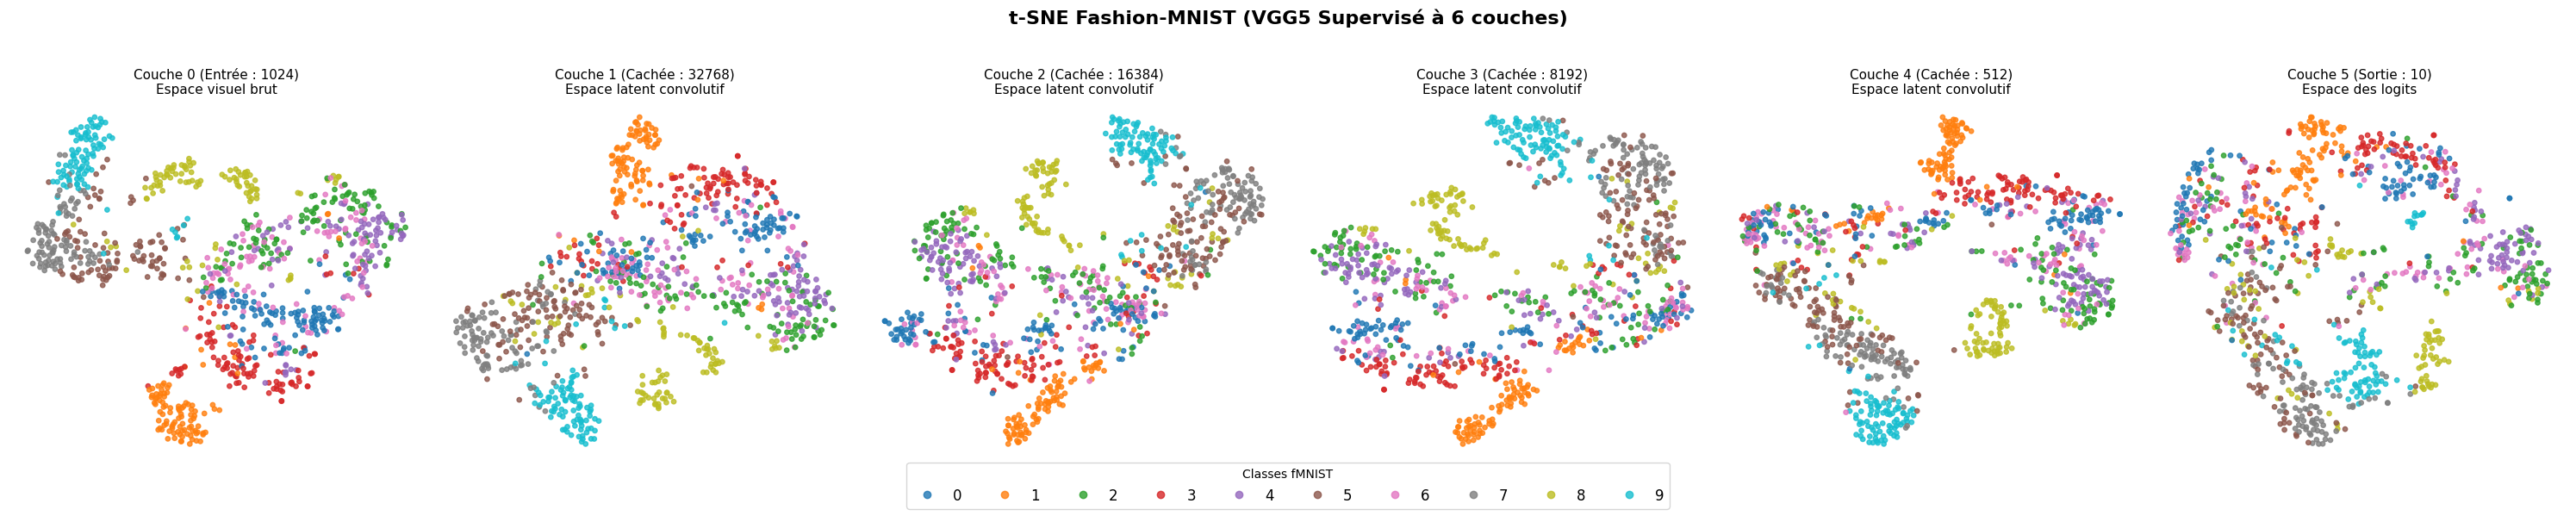

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# VISUALISATION t-SNE POUR VGG5
# ---------------------------------------------------------
vgg5_fmnist=vgg5_fmnist
vgg5_fmnist.eval()
num_samples = 1000

# Le VGG5 a 6 niveaux d'états (L=6)
num_layers = vgg5_fmnist.L
latents_per_layer = [[] for _ in range(num_layers)]
targets_tsne = []

print(f"Extraction des {num_layers} couches du modèle VGG5...")

for images, labels in datasets["fMNIST"]["val"]:
    # L'image reste au format (B, C, H, W) pour entrer dans la convolution
    x_in = images.to(device)
    batch_size = x_in.size(0)
    
    # Inférence
    x_init = vgg5_fmnist.bottom_up_sweep(x_in)
    x_infer = vgg5_fmnist.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # Extraction dynamique avec aplatissement pour t-SNE
    for i in range(num_layers):
        # On aplatit chaque état latent : (B, C, H, W) -> (B, C*H*W)
        flat_tensor = x_infer[i].view(batch_size, -1).detach().cpu().numpy()
        latents_per_layer[i].append(flat_tensor)
        
    targets_tsne.append(labels.numpy())
    
    if sum(len(t) for t in targets_tsne) >= num_samples: 
        break

# Concaténation dynamique
Z_layers = [np.concatenate(latents)[:num_samples] for latents in latents_per_layer]
Y_tsne = np.concatenate(targets_tsne)[:num_samples]

# ---------------------------------------------------------
# AFFICHAGE
# ---------------------------------------------------------
fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 6))

if num_layers == 1: axes = [axes]

fig.suptitle(f"t-SNE Fashion-MNIST (VGG5 Supervisé à {num_layers} couches)", fontsize=16, fontweight='bold')
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')

for i in range(num_layers):
    ax = axes[i]
    print(f"Calcul t-SNE pour la couche {i}...")
    
    z_tsne = tsne.fit_transform(Z_layers[i])
    sc = ax.scatter(z_tsne[:, 0], z_tsne[:, 1], c=Y_tsne, cmap='tab10', s=15, alpha=0.8)
    
    # Calcul du nombre total de caractéristiques (Features) pour le titre
    layer_features = Z_layers[i].shape[1]
    
    if i == 0:
        title = f"Couche 0 (Entrée : {layer_features})\nEspace visuel brut"
    elif i == num_layers - 1:
        title = f"Couche {i} (Sortie : {layer_features})\nEspace des logits"
    else:
        title = f"Couche {i} (Cachée : {layer_features})\nEspace latent convolutif"
        
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, labels_plot = sc.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes fMNIST", fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [1]:
print("\n--- ÉVALUATION CIFAR-10 (MODÈLE SUPERVISÉ) ---")
vgg5_fmnist.eval()

total_correct_sup = 0
total_comp_mse_sup = 0
total_samples_sup = 0
epsilon_sup = 1e-5

# Masque pour la complétion (moitié haute conservée)
channels, h, w = datasets["fMNIST"]["shape"]
mask_2d_sup = torch.zeros((channels, h, w), device=device)
mask_2d_sup[:, :h//2, :] = 1.0  
missing_ratio_sup = 0.50

for images, labels in datasets["fMNIST"]["val"]:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # 1. CLASSIFICATION NATIVE
    # ---------------------------------------------------------
    x_init_class = vgg5_fmnist.bottom_up_sweep(x1_input)
    # On fige l'entrée, on laisse la couche 2 converger vers la prédiction
    x_res_class = vgg5_fmnist.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
    preds = torch.argmax(x_res_class[-1], dim=1)
    total_correct_sup += (preds == labels).sum().item()
    
    # ---------------------------------------------------------
    # 2. COMPLÉTION (Moitié Basse)
    # ---------------------------------------------------------
    known_mask = mask_2d_sup.view(-1).unsqueeze(0).expand_as(x1_input)
    missing_mask = 1.0 - known_mask
    occluded_images = x1_input * known_mask
    
    x_init_comp = vgg5_fmnist.bottom_up_sweep(occluded_images)
    x_comp = [t.clone().detach() for t in x_init_comp]
    for i in range(vgg5_fmnist.L): x_comp[i].requires_grad = True
    opt_comp = optim.SGD(x_comp, lr=0.01)
    
    # Phase 1: Warm-up
    orig_alpha_disc = vgg5_fmnist.alpha_disc
    vgg5_fmnist.alpha_disc = 0.0
    prev_en = float('inf')
    for _ in range(500):
        opt_comp.zero_grad()
        en = vgg5_fmnist.compute_energy(x_comp)
        en.backward()
        x_comp[0].grad.data *= missing_mask
        opt_comp.step()
        if abs(prev_en - en.item()) < epsilon_sup: break
        prev_en = en.item()
        
    # Phase 2: Bidirectionnel
    vgg5_fmnist.alpha_disc = orig_alpha_disc
    prev_en = float('inf')
    for _ in range(500):
        opt_comp.zero_grad()
        en = vgg5_fmnist.compute_energy(x_comp)
        en.backward()
        x_comp[0].grad.data *= missing_mask
        opt_comp.step()
        if abs(prev_en - en.item()) < epsilon_sup: break
        prev_en = en.item()
        
    diff_comp = (x_comp[0].detach() - x1_input) * missing_mask
    total_comp_mse_sup += torch.sum(diff_comp ** 2).item()
    
    total_samples_sup += batch_size

acc_sup = 100 * total_correct_sup / total_samples_sup
rmse_comp_sup = math.sqrt(total_comp_mse_sup / (total_samples_sup * 3072 * missing_ratio_sup))

print(f"-> Précision de classification : {acc_sup:.2f}%")
print(f"-> RMSE Complétion (moitié basse) : {rmse_comp_sup:.4f}")


--- ÉVALUATION CIFAR-10 (MODÈLE SUPERVISÉ) ---


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [256, 1024]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# DÉFINITION DU MODÈLE À TESTER
# (Assure-toi que ce modèle a été entraîné sur fMNIST au préalable)
# ---------------------------------------------------------
current_model = vgg5_fmnist 
current_model.eval()

num_samples = 1000

# Création d'une liste de listes vide pour chaque couche du modèle
latents_per_layer = [[] for _ in range(current_model.L)]
targets_tsne = []

print(f"Extraction des {current_model.L} couches du modèle...")

for images, labels in datasets["fMNIST"]["val"]:
    x_in = images.view(images.size(0), -1).to(device)
    
    # Inférence
    x_init = current_model.bottom_up_sweep(x_in)
    x_infer = current_model.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # Extraction dynamique pour chaque couche
    for i in range(current_model.L):
        latents_per_layer[i].append(x_infer[i].detach().cpu().numpy())
        
    targets_tsne.append(labels.numpy())
    
    if sum(len(t) for t in targets_tsne) >= num_samples: 
        break

# Concaténation dynamique
Z_layers = [np.concatenate(latents)[:num_samples] for latents in latents_per_layer]
Y_tsne = np.concatenate(targets_tsne)[:num_samples]

# ---------------------------------------------------------
# AFFICHAGE DYNAMIQUE
# ---------------------------------------------------------
num_layers = current_model.L
# La largeur de la figure s'adapte au nombre de couches (5 pouces par couche)
fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 6))

# Si le modèle n'avait que 1 couche (peu probable, mais sécurisé), axes n'est pas une liste
if num_layers == 1:
    axes = [axes]

fig.suptitle(f"t-SNE Fashion-MNIST (Modèle Dynamique à {num_layers} couches)", fontsize=16, fontweight='bold')

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')

for i in range(num_layers):
    ax = axes[i]
    print(f"Calcul t-SNE pour la couche {i}...")
    
    z_tsne = tsne.fit_transform(Z_layers[i])
    sc = ax.scatter(z_tsne[:, 0], z_tsne[:, 1], c=Y_tsne, cmap='tab10', s=15, alpha=0.8)
    
    layer_size = Z_layers[i].shape[1]
    
    # Titres dynamiques selon la position de la couche
    if i == 0:
        title = f"Couche 0 (Entrée : {layer_size})\nEspace visuel brut"
    elif i == num_layers - 1:
        title = f"Couche {i} (Sortie : {layer_size})\nEspace des prédictions"
    else:
        title = f"Couche {i} (Cachée : {layer_size})\nEspace latent intermédiaire"
        
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# Légende globale
handles, labels_plot = sc.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes fMNIST", fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

Extraction des 6 couches du modèle...


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [256, 1024]

In [ ]:
import torch.optim as optim

def train_bpc_model(model, dataloader, epochs=25, is_mixed=False):
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)
    latent_mask = torch.zeros(30, device=device)
    if is_mixed:
        latent_mask[:10] = 1.0
        
    for epoch in range(epochs):
        model.train()
        total_energy = 0
        for images, labels in dataloader:
            x1_input = images.view(images.size(0), -1).to(device)
            x_init = model.bottom_up_sweep(x1_input)
            x_init[0] = x1_input
            
            if is_mixed:
                xL_label = torch.zeros((x1_input.size(0), 30), device=device)
                xL_label[:, :10] = torch.nn.functional.one_hot(labels, num_classes=10).float()
                x_init[-1][:, :10] = xL_label[:, :10]
                x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, partial_clamp=(2, latent_mask.unsqueeze(0)))
            else:
                x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, activity_decay=1e-4)
                
            optimizer.zero_grad()
            loss = model.compute_energy(x_inferred)
            loss.backward()
            optimizer.step()
            total_energy += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Énergie : {total_energy/len(dataloader):.4f}")
    return model

# ---------------------------------------------------------
# INSTANCIATION ET ENTRAÎNEMENT POUR FASHION-MNIST
# ---------------------------------------------------------
print("--- ENTRAÎNEMENT FASHION-MNIST ---")
fmnist_unsup = BidirectionalPC(layer_sizes=[784, 450, 30], alpha_gen=1.0, alpha_disc=1.0).to(device)
fmnist_mixed = MixedBidirectionalPC(layer_sizes=[784, 450, 30], alpha_gen=1e-4, alpha_disc=1.0).to(device)

print("Entraînement fMNIST Non-Supervisé :")
fmnist_unsup = train_bpc_model(fmnist_unsup, datasets["fMNIST"]["train"], epochs=25, is_mixed=False)
print("Entraînement fMNIST Mixte :")
fmnist_mixed = train_bpc_model(fmnist_mixed, datasets["fMNIST"]["train"], epochs=25, is_mixed=True)

# ---------------------------------------------------------
# INSTANCIATION ET ENTRAÎNEMENT POUR CIFAR-10
# ---------------------------------------------------------
print("\n--- ENTRAÎNEMENT CIFAR-10 ---")
cifar_unsup = BidirectionalPC(layer_sizes=[3072, 450, 30], alpha_gen=1.0, alpha_disc=1.0).to(device)
cifar_mixed = MixedBidirectionalPC(layer_sizes=[3072, 450, 30], alpha_gen=1e-4, alpha_disc=1.0).to(device)

print("Entraînement CIFAR-10 Non-Supervisé :")
cifar_unsup = train_bpc_model(cifar_unsup, datasets["CIFAR10"]["train"], epochs=25, is_mixed=False)
print("Entraînement CIFAR-10 Mixte :")
cifar_mixed = train_bpc_model(cifar_mixed, datasets["CIFAR10"]["train"], epochs=25, is_mixed=True)

In [ ]:
import math
import torch.nn as nn

def evaluate_model(model, dataloader, ds_info, is_mixed=False):
    model.eval()
    input_dim = ds_info["input_dim"]
    channels, h, w = ds_info["shape"]
    
    # Masque Géométrique adapté à l'image
    mask_2d = torch.zeros((channels, h, w), device=device)
    mask_2d[:, :h//2, :] = 1.0  # Conserve la moitié haute
    
    total_recon_mse, total_comp_mse = 0, 0
    total_correct_native = 0
    total_samples = 0
    epsilon = 1e-5
    
    for images, labels in dataloader:
        x1_input = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        batch_size = x1_input.size(0)
        
        # 1. RECONSTRUCTION
        x_init_enc = model.bottom_up_sweep(x1_input)
        x_enc = [t.clone().detach() for t in x_init_enc]
        for i in range(1, model.L): x_enc[i].requires_grad = True
        opt_enc = optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
        prev_en = float('inf')
        for _ in range(500):
            opt_enc.zero_grad()
            en = model.compute_energy(x_enc)
            en.backward()
            opt_enc.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        x_init_dec = model.top_down_sweep(x_enc[-1].detach())
        x_dec = [t.clone().detach() for t in x_init_dec]
        for i in range(model.L - 1): x_dec[i].requires_grad = True
        opt_dec = optim.SGD([x_dec[i] for i in range(model.L - 1)], lr=0.01)
        prev_en = float('inf')
        for _ in range(500):
            opt_dec.zero_grad()
            en = model.compute_energy(x_dec)
            en.backward()
            opt_dec.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        total_recon_mse += torch.sum((x_dec[0].detach() - x1_input) ** 2).item()
        
        # 2. COMPLÉTION
        known_mask = mask_2d.view(-1).unsqueeze(0).expand_as(x1_input)
        missing_mask = 1.0 - known_mask
        
        x_init_comp = model.bottom_up_sweep(x1_input * known_mask)
        x_comp = [t.clone().detach() for t in x_init_comp]
        for i in range(model.L): x_comp[i].requires_grad = True
        opt_comp = optim.SGD(x_comp, lr=0.01)
        
        # Phase 1: Warm-up
        orig_alpha_disc = model.alpha_disc
        model.alpha_disc = 0.0
        prev_en = float('inf')
        for _ in range(500):
            opt_comp.zero_grad()
            en = model.compute_energy(x_comp)
            en.backward()
            x_comp[0].grad.data *= missing_mask
            opt_comp.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        # Phase 2: Bidirectionnel
        model.alpha_disc = orig_alpha_disc
        prev_en = float('inf')
        for _ in range(500):
            opt_comp.zero_grad()
            en = model.compute_energy(x_comp)
            en.backward()
            x_comp[0].grad.data *= missing_mask
            opt_comp.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        diff_comp = (x_comp[0].detach() - x1_input) * missing_mask
        total_comp_mse += torch.sum(diff_comp ** 2).item()
        
        # 3. CLASSIFICATION NATIVE (Si Mixte)
        if is_mixed:
            x_init_class = model.bottom_up_sweep(x1_input)
            x_res_class = model.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
            preds = torch.argmax(x_res_class[-1][:, :10], dim=1)
            total_correct_native += (preds == labels).sum().item()
            
        total_samples += batch_size

    rmse_recon = math.sqrt(total_recon_mse / (total_samples * input_dim))
    rmse_comp = math.sqrt(total_comp_mse / (total_samples * input_dim * 0.5))
    
    print(f"  -> RMSE Reconstruction: {rmse_recon:.4f}")
    print(f"  -> RMSE Complétion (bas): {rmse_comp:.4f}")
    if is_mixed:
        print(f"  -> Précision Native: {100 * total_correct_native / total_samples:.2f}%")

print("\n--- ÉVALUATION FASHION-MNIST ---")
print("[Non-Supervisé]")
evaluate_model(fmnist_unsup, datasets["fMNIST"]["val"], datasets["fMNIST"], is_mixed=False)
print("[Mixte]")
evaluate_model(fmnist_mixed, datasets["fMNIST"]["val"], datasets["fMNIST"], is_mixed=True)

print("\n--- ÉVALUATION CIFAR-10 ---")
print("[Non-Supervisé]")
evaluate_model(cifar_unsup, datasets["CIFAR10"]["val"], datasets["CIFAR10"], is_mixed=False)
print("[Mixte]")
evaluate_model(cifar_mixed, datasets["CIFAR10"]["val"], datasets["CIFAR10"], is_mixed=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(model_unsup, model_mixed, dataloader, title_prefix):
    model_unsup.eval()
    model_mixed.eval()
    
    latents_u, latents_m, targets = [], [], []
    num_samples = 1000
    
    for images, labels in dataloader:
        x_in = images.view(images.size(0), -1).to(device)
        
        # Extraction Unsup
        xu_init = model_unsup.bottom_up_sweep(x_in)
        xu = [t.clone().detach() for t in xu_init]
        for i in range(1, model_unsup.L): xu[i].requires_grad = True
        op_u = optim.SGD([xu[i] for i in range(1, model_unsup.L)], lr=0.01)
        for _ in range(100):
            op_u.zero_grad()
            model_unsup.compute_energy(xu).backward()
            op_u.step()
            
        # Extraction Mixte
        xm_init = model_mixed.bottom_up_sweep(x_in)
        xm = [t.clone().detach() for t in xm_init]
        for i in range(1, model_mixed.L): xm[i].requires_grad = True
        op_m = optim.SGD([xm[i] for i in range(1, model_mixed.L)], lr=0.01)
        for _ in range(100):
            op_m.zero_grad()
            model_mixed.compute_energy(xm).backward()
            op_m.step()
            
        latents_u.append(xu[-1].detach().cpu().numpy())
        latents_m.append(xm[-1].detach().cpu().numpy())
        targets.append(labels.numpy())
        
        if sum(len(t) for t in targets) >= num_samples: break
            
    Z_u = np.concatenate(latents_u)[:num_samples]
    Z_m = np.concatenate(latents_m)[:num_samples]
    Y = np.concatenate(targets)[:num_samples]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"t-SNE Espace Latent (Couche Supérieure) - {title_prefix}", fontsize=14, fontweight='bold')
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    
    ax1 = axes[0]
    z_u_tsne = tsne.fit_transform(Z_u)
    sc1 = ax1.scatter(z_u_tsne[:, 0], z_u_tsne[:, 1], c=Y, cmap='tab10', s=15, alpha=0.8)
    ax1.set_title("Modèle Non-Supervisé")
    ax1.axis('off')
    
    ax2 = axes[1]
    z_m_tsne = tsne.fit_transform(Z_m)
    ax2.scatter(z_m_tsne[:, 0], z_m_tsne[:, 1], c=Y, cmap='tab10', s=15, alpha=0.8)
    ax2.set_title("Modèle Mixte")
    ax2.axis('off')
    
    handles, labels_plot = sc1.legend_elements()
    fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes")
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

# Affichage pour fMNIST
plot_tsne_comparison(fmnist_unsup, fmnist_mixed, datasets["fMNIST"]["val"], "Fashion-MNIST")

# Affichage pour CIFAR-10
plot_tsne_comparison(cifar_unsup, cifar_mixed, datasets["CIFAR10"]["val"], "CIFAR-10")